To see a video presentation of the below project, see here (~24 minutes): [https://www.youtube.com/watch?v=FWyuVph7NqM](https://www.youtube.com/watch?v=FWyuVph7NqM)

# Abstract

The goal of this project is to explore the concept of Kernel Density Estimation (K.D.E.) to better understand the theory along with how it can be practically applied for individual use by researchers. Density estimation is an important topic as it is used to better get a picture of the underlying [*probability density function*](https://en.wikipedia.org/wiki/Probability_density_function) for a variable. The probability density can be thougth of as the likelihood for a random variable to take on a point (discrete) or a range of values (continuous). For the purposes of this presentation, it will be simple enough to think of variables as coming from a continuous distribution. In the project, the theory of density estimation will be explored to better understand the methods. It will be shown that the Sheather-Jones method is the only practical method for obtaining a bandwidth (i.e., first parameter) and that it should likely be used in combination with a Normal kernel function (i.e., second / last parameter). In the end, some notable applications along with an example on two datasets will be overviewed to better grasp how a researcher may choose to make use of K.D.E. in their research.

# Table of Contents
<a id="top"></a>
## Theory Piece
1.	[Introduction](#introduction)
2.	[History](#history)
3.	[Histograms](#histograms)
4.	[Kernel Density Estimation](#kde)
    + 4.1	[Exploratory Data Analysis](#eda)
    + 4.2	[Math](#math)
        + 4.2.1	[Optimal Bandwidth](#ob)
        + 4.2.1.1	[Cross-Validation](#cv)
        + 4.2.1.2	[Plug-in Methods](#pm)
        + 4.2.1.3	[Maximal Smoothing Principle](#msp)
        + 4.2.2	[Optimal Kernel Function](#okf)
5.	[Notable Applications](#na)

## Computational Piece
1.	[Pipeline](#pipeline)
2.	[Dataset 1 (Diabetes)](#d1)
3.	[Dataset 2 (Wine)](#d2)
4.  [Conclusion](#conclusion)

## References
1. [Bibliography](#bibliography)
2. [Code Appendix](#ca)

# Theory Piece

# 1. Introduction
<a id="introduction"></a>
<a href="#top">Back to top</a>

The focus of this project is on the topic of ‘Density Estimation.’ For students that have studied some of the basics of probability and statistics, it’s simple to think of the real world through the lens of theoretical distributions that are easily generated from by utilizing a set of functions in RStudio (e.g., rnorm, runif, etc.). However, in the real world, phenomena that can be recorded as data may come from a variety of distributions that don’t fit well into the commonly covered probability distributions found in textbooks (e.g., normal distribution, Poisson distribution, binomial distribution, etc.). For example, it’s possible to think of the time between geyser eruptions for Old Faithful from Yellowstone National Park as being a random variable. The ‘true’ probability distribution function (i.e., the p.d.f. denoted $f(x)$) for this data is unknown, but it can be estimated using techniques from ‘Density Estimation.’ To be specific, the focus of this project will be on that of Kernel Density Estimation (K.D.E.).

Below in Figure 1 on the left is a simple frequency histogram of the waiting times for Old Faithful based on the default dataset in R called faithful (this seems to be a common example, referenced in multiple sources for K.D.E.). On the $x$-axis are the minutes between eruptions, and it ranges from $40$ to $100$. This representation of count data is a rather standard way to analyze quantitative variables within a dataset. On the right of Figure 1 is the same data, however changed into a density histogram where the $y$-axis reflects the proportions of data falling along certain ranges of the $x$-axis instead of the frequency.


```
### Fig. 1
# Compare frequency and density histograms
par(mfrow = c(1,2))
hist(faithful$waiting, main = 'Frequency Histogram of Waiting Times Between Eruptions',
     xlab = 'Time Between Eruptions (minutes)')
hist(faithful$waiting, main = 'Density Histogram Waiting Times Between Eruptions',
     xlab = 'Time Between Eruptions (minutes)', freq = FALSE)
lines(density(faithful$waiting))
dev.off()
```

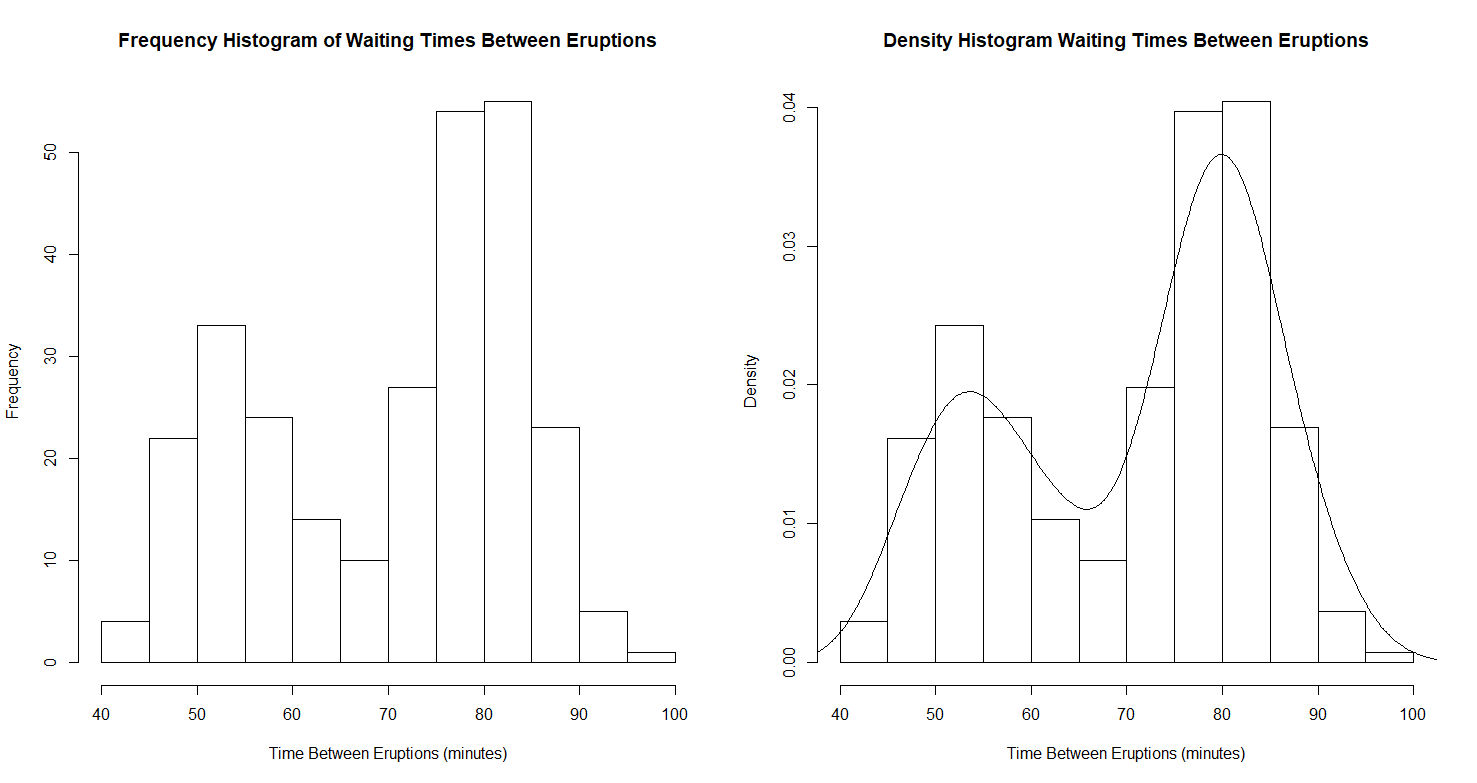

*Figure 1 A frequency histogram on the left and a density histogram on the right that is fitted with the density function in R.*


By changing the histogram from a frequency histogram to a density histogram there’s now the case where the sum of the areas of the bins (i.e., $height \times width$) is equal to $1$. The histogram now seems much more like the familiar p.d.f. where the area under the curve is also equal to $1$. Additionally, a line has been drawn using the density() function in R (this function automatically calculates kernel density estimates) that represents the curve of the p.d.f. regularly seen from theoretical distributions within textbooks. Thinking of this curve as the estimated p.d.f. (i.e., $\hat{f}(x)$ or the estimator of the density) for the random variable, it’s clear that it has a shape that is unfamiliar and therefore not quite like any of the typical distributions learned within introductory textbooks. A possible guess is that it’s more like a mixture of two normal distributions.

The focus of this project then will be on understanding the process of how an estimated p.d.f. can be fitted to a given dataset and the possibilities that it allows for researchers. Additionally, there will be applications found within literature that help to show how doing this form of exploratory data analysis using density estimates (a curved line) rather binned histograms can be beneficial and practical for researchers.

# 2. History
<a id="history"></a>
<a href="#top">Back to top</a>

Within the field of statistics and along with this course, the technique is called K.D.E. Another name from other fields is the Parzen-Rosenblatt window, two statisticians who are credited with helping to derive the technique. Murray Rosenblatt was the first in 1958 to develop a technique that can perform nonparametric estimates of density functions. Later in 1962, Emmanuel Parzen would be the third author to expand on the topic (Parzen references a paper by Whittle in 1958) where his approach includes the familiar usage of kernels to complete the process of density estimation. Parzen mentions in the introduction that density estimation is an interesting subject since it can have many practical purposes. The application that he mentions is the hazard rate, which is important for engineers to determine the time at which a component may be expected to fail. Over the decades, different techniques have been researched and developed by different people and there continues to be new methodologies being developed even to today. It’s a method that helps researchers to understand variables from an exploratory data analysis point of view, amongst other applications that it has been used for.


# 3. Histograms
<a id="histograms"></a>
<a href="#top">Back to top</a>

The famous statistician Karl Pearson first introduced the histogram in 1891. Histograms (as seen in Figure 1) are the first types of density estimation that have been made available. They divide data into ranges as bins and the height of the bins help to determine the frequency of data within those ranges. They’re like bar charts which came before, but instead of suiting categorical variables they work well with continuous variables. Furthermore, bar charts generally will have gaps between the bars. The differences between the two can be seen below in Figure 2.


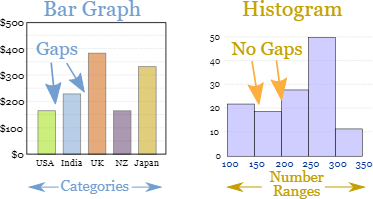

*Figure 2 Comparison between Bar Chart and Histogram. (Source: mathisfun.com)*


There are different ways of writing the formula to compute the output of the histogram. The following formula itself will return the histogram estimate of the probability that an observation will lie within an interval given a dataset. It’s important to note that the following will calculate the densities expressed as horizontal lines in a density histogram rather than draw the vertical lines that help to represent them as rectangles (this will be elaborated on later). Using the paper by Silverman (1986), the formula is as follows (equation 1),

$$\hat{f}(x) = \frac{1}{n} \times \frac{\text{no. of } X_i \text{ in the same bin as } x}{\text{width of bin containing } x}$$

In the formula, $n$ refers to the number of observations and $X_i$ are observations in the dataset. The choice of determining the bin widths (denoted $h$ in Silverman) can be done a priori or in some manner that the user decides works best. In other words, it’s a subjective process that depends on the user. The above formula (equation 1) refers to the height of a bin at point $x$ on the x-axis. The bins of the histogram are defined as follows (equation 2),

$$[x_0 + mh, x_0 + (m+1)h].$$

Here $x_0$ is the origin (for example in Figure 1 $x_0=100$), $h$ is the bin width (for example in Figure 1 $h=50$), and $m$ is some positive or negative integer (in Figure 1 m appears to be $1$).

Although helpful when doing exploratory data analysis on a variable, histograms have problems that are inherent in how they’re designed. An example is below in Figure 3 where the same data for Old Faithful is shown again. On the left-hand side is the same as the left-hand side part of Figure 1. On the right-hand side however is when the number of break points is set to 20. The total number of bins is 27, which is not the same as 20 bins like in the argument. The argument of works hist(breaks=) such that it’s required to input a vector of break points for the exact intervals of each of the bins (this approach is more ad-hoc and a more elaborate approach will be shown later). However, simply inputting a single integer performs a similar task that does the job also.

```
### Fig. 3
# Compare density histograms for different number of bins
par(mfrow = c(1,2))
hist(faithful$waiting, main = 'Frequency Histogram of Waiting Times Between Eruptions (breaks=default)',
     xlab = 'Time Between Eruptions (minutes)')
hist(faithful$waiting, main = 'Frequency Histogram of Waiting Times Between Eruptions (breaks=20)',
     xlab = 'Time Between Eruptions (minutes)', breaks = 20)
dev.off()
```

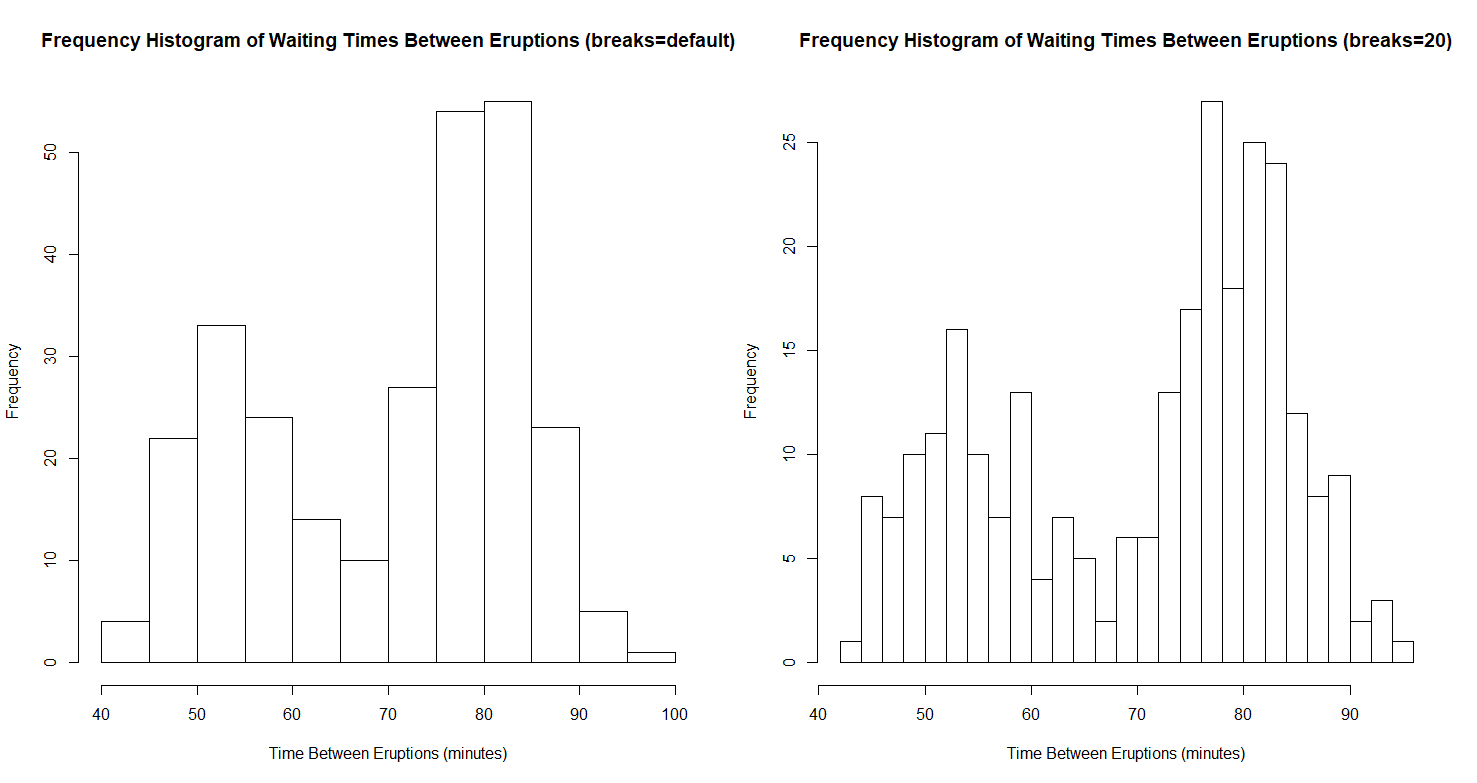

*Figure 3 The histogram on the left is the same as Fig. 1 on the left and on the right the number of breakpoints is increased to 20.*

In Figure 3 the difference between the two histograms is quite noticeable. Before there were clearly two main peaks making for a bimodal distribution. However, after increasing the number of bins, it seems that there could still be two main peaks, but each of them can then be further broken down into minor peaks. Silverman notes that this differentiate is problematic for non-statisticians who lack experience analyzing data through such means. Another problem noted by Silverman is the inability to take derivatives in cases where it’s required.

The prevalence of such issues makes it such that it’s worthwhile to investigate other means to perform density estimation. The p.d.f. of a random variable is such an important topic to many different fields to the point where researching alternatives to the histogram is worth the effort. Even if they aren’t as popular, they still have many practical uses that can be highlighted in case-by-case situations. Next, the alternative method for estimating densities with Kernel Density Estimation (K.D.E.) will be explored.


# 4. Kernel Density Estimation (K.D.E.)
<a id="kde"></a>
<a href="#top">Back to top</a>

An issue with utilizing K.D.E. goes back to a problem with histograms. The K.D.E. curve that is applied over the histogram in Figure 1 isn’t always so simple to fit. The fact that histograms have parameters related to the number of bins means that it’s already up to the researcher to determine subjectively an appropriate number of bins before fitting a K.D.E. curve. The issue then is that the curve may fit nicely for certain histograms while appear to fit poorly for other histograms with more or fewer bins. An example of this can be seen below in Figure 4. The data is the natural logarithm of the dataset ‘F12.txt.’ The grid contains histograms for varying $m$ number of bins where $m=10, 20,\cdots, 60$ (Note: Here, the variable $m$ coincides with the number of bins where before it had come from the formula from Silverman’s paper). To do this, it’s necessary to calculate the individual break points for the bins as a function of the range of the dataset and the parameter m.

```
### Fig. 4
### The hist_est() function plots a histogram after separating the
### data into m intervals.
hist_est <- function(var1 = f12, m = 30, hist_tile, hist_x_lab, line_color = 'black') {
  var1_range <- range(var1) # range of data
  D <- var1_range[2] - var1_range[1] # ~length D of histogram
  v_k <- D / m # volume of bin (length of interval)
  n <- length(var1)
  
  break_pts <- matrix(NA, nrow = m + 1)
  break_pts[1] <- var1_range[1]; break_pts[m + 1] <- var1_range[2]
  for (i in 1:(m - 1)) { 
    break_pts[i + 1] <- var1_range[1] + i * v_k # possible bias towards right side
  } # create (m + 1) intervals
  break_pts <- as.vector(break_pts)
  
  m_bins <- matrix(0, nrow = m)
  for (i in var1) {
    lower_interval <- tail(which(i > break_pts), 1)
    if (i == break_pts[1]) { # edge case for smallest value
      m_bins[1] <- m_bins[1] + 1
    }
    m_bins[lower_interval] <- m_bins[lower_interval] + 1
  } # calculate the number of obs. in each bin
  
  p_k <- m_bins / n # proportion per bin
  f_hat <- p_k / v_k # est. histogram output
  
  # y_limits <- c(-0.05, max(f_hat_pts) + 0.5 * sd(f_hat_pts))
  y_limits <- c(0, max(f_hat) + 1e-2)
  # Reference: https://stackoverflow.com/questions/4785657/how-to-draw-an-empty-plot
  plot(1, type="n", ylab= "Estimated Density", xlim = var1_range, ylim = y_limits,
       main = paste0(hist_tile, ' (m=', m,')'),
       xlab = hist_x_lab)
       # main = paste0('Histogram Estimator (m=', m,')'))
  abline(h = 0)
  for (i in 1:length(f_hat)) {
    lines(c(break_pts[i], break_pts[i+1]), c(f_hat[i], f_hat[i]),
          col = line_color)
  } # plot horizontal and vertical lines of histogram
  segments(x0 = break_pts[-1], y0 = 0, x1 = break_pts[-1], y1 = f_hat, col = line_color)
  segments(x0 = break_pts[-length(break_pts)],
           y0 = 0, x1 = break_pts[-length(break_pts)], y1 = f_hat, col = line_color)
}

f12 <- read.csv('F12.txt', header = FALSE) # load data
f12 <- log(f12[[1]]) # take log
par(mfrow = c(3,2)) # Plot grid of histograms for different 'm' bins
m_vec <- seq(from = 10, to = 60, length.out = 6)
for (i in m_vec) {
  hist_est(var1 = f12, m = i, hist_tile = 'Histogram of log F12',
           hist_x_lab = 'log F12')
  lines(density(f12))
}
dev.off()
```

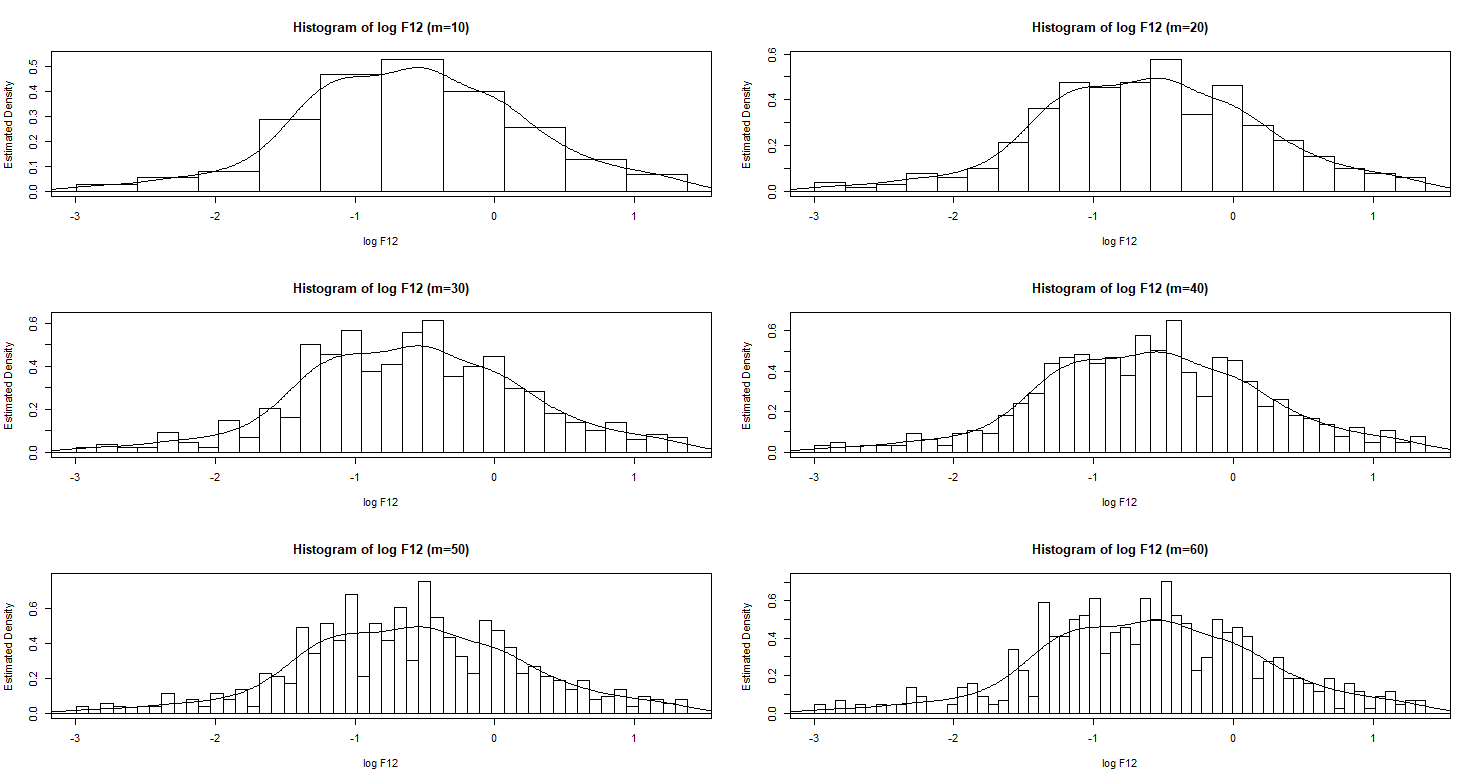

*Figure 4 A grid of six histogram plots with varying bin sizes ($m=10, 20, \cdots, 60$).*


In the above histograms, the same K.D.E. curve is fit using the R command lines(density(f12)) (where f12 is the natural log of the F12.txt dataset). So, in each of the plots the same K.D.E. curve is identical. However, each of the histograms are manually generated using a formula in the format of the histogram equation (shown previously). The K.D.E. curve itself seems to be a general bell-shaped curve while subtly also showing three peaks that make up the unimodal appearance. In the histogram with m$=10$ bins, the subtle peaks in the K.D.E. curve seem to be overfitting the data. Yet, when looking at $m=40$ bins, it becomes clear that those subtle peaks in the K.D.E. curve correspond with actual characteristics of the sample density. In the plot for $m=40$ bins, it’s possible to see that there are unique peaks in the histogram estimate around $-1$, $-0.5$, and $0$.

The issue then is that it becomes up to the researcher to determine whether such characteristics of the histogram estimate based on the sample data are important or not. This is an example of how K.D.E. is particularly effective for exploratory data analysis purposes. In this example, using just histograms makes it uncertain to discern whether the data follows a simple unimodal distribution or if there’s a more complicated nature to the underlying data’s distribution. By combining the two and doing an overlay through different numbers of bins, the K.D.E. can help to confirm that there’s a real possibility that the data has special traits that are worth paying attention to. When researchers notice these subtleties, it’s possible for them to do further investigation on the variable of interest to try and understand if progress can be made within their corresponding fields. Next, it will be shown some brief examples of how this is possible.

*Note: The recommended formula for the number of bins is $1 + log_2n$, however in the above f12 dataset this rounds to $10$. It's evident that for $m=10$ however that the histogram fails to emphasize the subtler bumps in the density.*


# 4.1	Exploratory Data Analysis
<a id="eda"></a>
<a href="#top">Back to top</a>

It will quickly be mentioned in this section what is meant by exploratory data analysis. Typically, when a new dataset is encountered, to understand the wide set of variables that the dataset may have, it’s often useful to analyze them utilizing histograms. This is a conventional approach towards beginning to find insights and draw conclusions from a set of data. To be specific, it’s useful for variables that are of a continuous data type.

However, as it’s been made note of previously, this method for analyzing variables is quite rough in its approach. There are no hard and fast rules for determining the number of bins to analyze a variable, and there’s no right answer. This is a decision for the researchers themselves to determine based on variables themselves and their knowledge of the variable’s characteristics. Rather than simply being an alternative that can fix all of these issues, K.D.E. when used in combination with histograms during the exploratory data analysis process can look more carefully at these individual variables to try and better understand them for the purposes of further research. The K.D.E. curves make it possible for researchers to gain an additional edge in trying to analyze data so that they can possibly have the hopes of finding new insights and making further discoveries.

In terms of advantages and disadvantages, it’s certainly the case that having the extra tool of K.D.E. gives researchers a greater ability to investigate and derive more insights from a dataset. The combination of the two makes it such that details that were before unnoticed due to the discrete bins are made apparent with the continuous curve created with K.D.E. Yet, it could be said that a disadvantage is that it’s still a modeling technique that is used like histograms themselves. Researchers must be able to take the time and go through the process of analyzing each of the continuous variables and apply different kernel functions and bandwidths to be more certain of their analysis. In certain datasets, this perhaps isn’t feasible since there are too many variables and so they could only analyze a subset. Beyond being more time consuming than applying a simple histogram is that in the end it could possibly lead to no new ideas about the data itself. This is an unfortunate situation and is just one of the realities that researchers themselves must overcome when trying to better understand a dataset.

A quick note to be made also is that K.D.E. isn’t exclusively for the purpose of exploratory data analysis. An example of this is in the final application shown in the Notable Applications section. However, for the typical researcher their interest in implementing K.D.E. themselves would be for the purpose of exploratory data analysis. This clearly doesn’t mean however that its usefulness is limited to this purpose. Any researcher that is innovative enough to find a novel application for this technique is welcome to do so.


# 4.2 Math
<a id="math"></a>
<a href="#top">Back to top</a>

Before going straight into the mathematical formula for K.D.E., it will first be stressed the difference between the binned histogram and the density estimate $\hat{f}(x)$. In Figure 5 below the histogram estimator is plotted as a black line that looks like a stepwise function. This line is the horizontal portion of the histograms that are normally seen. The vertical lines that are added to make them appear as bins is done for other reasons such as making it easier to visualize the distinct intervals separating the range of values. In this graph, it’s clearer to see how the histogram estimate is more like the K.D.E. estimate in that they are both estimating the underlying unknown p.d.f. of the data.


```
### Fig. 5
### The hist_est2() function provides the estimated probability based off
### the histogram estimate of the data. This is different
### from hist_est which plots the histogram.
hist_est2 <- function(x, var1 = f12, m = 30) {
  var1_range <- range(var1) # range of data
  
  # Check if x outside range of f-hat
  if ((x > var1_range[2]) | (x < var1_range[1])) {
    return(0)
  }
  
  D <- var1_range[2] - var1_range[1] # ~length D of histogram
  v_k <- D / m # volume of bin (length of interval)
  n <- length(var1)
  
  break_pts <- matrix(NA, nrow = m + 1)
  break_pts[1] <- var1_range[1]; break_pts[m + 1] <- var1_range[2]
  for (i in 1:(m - 1)) { 
    break_pts[i + 1] <- var1_range[1] + i * v_k # possible bias towards right side
  } # create (m + 1) intervals
  break_pts <- as.vector(break_pts)
  
  m_bins <- matrix(0, nrow = m)
  for (i in var1) {
    lower_interval <- tail(which(i > break_pts), 1)
    m_bins[lower_interval] <- m_bins[lower_interval] + 1
  } # calculate the number of obs. in each bin
  
  p_k <- m_bins / n # proportion per bin
  f_hat <- p_k / v_k # est. histogram output
  kth_bin <- tail(which(x >= break_pts), 1) # x's bin
  
  if ((kth_bin >= 1) & (kth_bin <= m)) {
    return(f_hat[kth_bin]) # return f-hat
  } else if (kth_bin == (m + 1)) {
    return(f_hat[m]) # edge case for last bin, return m'th bin
  } else {
    return(0)
  }
}

# vectorize the x argument
hist_est2_vec <- Vectorize(hist_est2, vectorize.args = c("x"))
xs <- seq(-3, 1.5, length.out = 1e4) # Plot the estimated histogram
plot(xs, hist_est2_vec(x = xs, var1 = f12, m = 40),
     type = 'l', main = 'Histogram Estimator and K.D.E. for log F12',
     xlab = 'log F12', ylab = 'Estimated Density')
lines(density(f12), lty = 2, col = 'red') # Add KDE for comparison
legend("topleft", legend = c('Histogram Estimator', 'K.D.E.'),
       lty = c(1,2), col = c('black', 'red'))
dev.off()

```

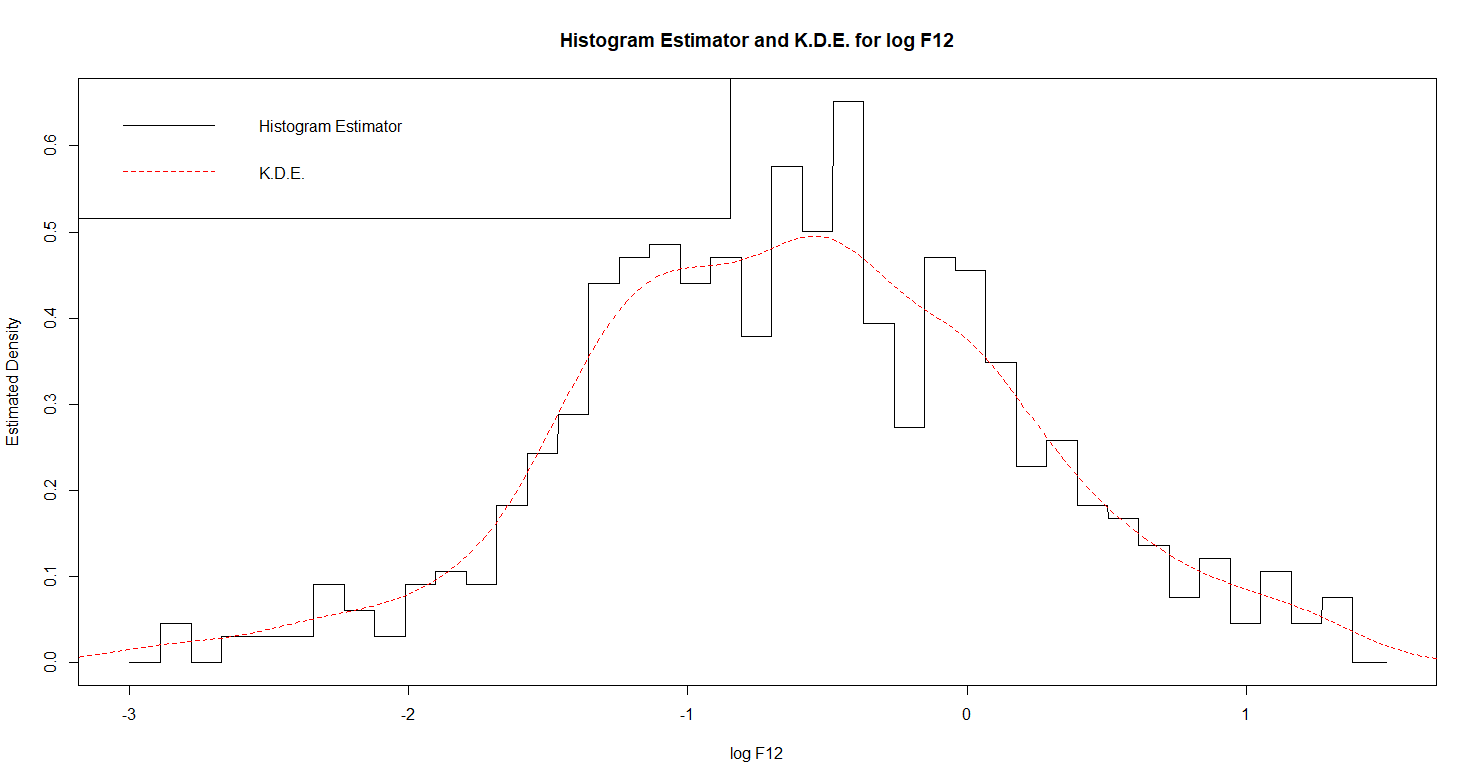

*Figure 5 The horizontal portions of the histogram (solid, black line) overlaid with K.D.E. curve (dashed, red line).*


The following is the formula for the K.D.E. function $\hat{f}(x)$ (equation 3),

$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^n K(\frac{x-X_i}{h}),$$

where $h$ is the chosen bandwidth, $K(\cdot)$ is a kernel function, and $X_i, i=1,\cdots,n$, is an observation from the dataset. For regular histograms, the bandwidth is analogous to the length of the interval for the bins. Thus far, the K.D.E. curves seen in the different figures have been created from the default density() function in R. According to the documentation, it defaults to using a bandwidth based on Silverman’s Rule of Thumb (explained later) for choosing a bandwidth and the standard normal distribution for the kernel function. From equation (3), it’s apparent that there are two parameters of interest for the function. These two parameters that must be chosen by the researcher are the bandwidth h and the kernel function $K(\cdot)$.

To better understand equation (3) itself, it makes sense to break it down into parts and think carefully about what’s going on. The function $\hat{f}(x)$ itself is like typical functions in that it takes an input from the $x$-axis and gives an output to the $y$-axis. Therefore, in the general case it will accept any value on the real number line, ${\rm I\!R}$, and output some value representing the estimated density. This output is some value greater than or equal to $0$. The reason that it’s not bounded by $1$ like with probabilities is that it’s estimating a continuous p.d.f. For continuous p.d.f.’s the height on the $y$-axis can go to infinity since the requirement is that the area under the curve integrates to $1$ (i.e., $\int_{-\infty}^{\infty}f(x)dx=1$).

So, we can take an example of $x=0$ as an input into equation (3). The dataset $\textbf{X}^\top=(X_1,\cdots,X_n)$ can be thought of a constant value for the function and doesn’t change throughout the estimated density. If a new dataset is used or the previous one is updated, then a new and separate evaluate of the K.D.E. is required. Using an example of a dataset with two observations, $X_1$ and $X_2$, the calculation of equation (3) is as follows (equation 4),

$$\hat{f}(0) = \frac{1}{2n}\cdot \left[K\left(\frac{(0)-X_1}{h}\right) + K\left(\frac{(0)-X_2}{h}\right)\right]$$

The function is taking an average of the difference of $x$ and all the observations $X_1,\cdots,X_n$ in the dataset divided by the bandwidth, after the kernel $K(\cdot)$ has been applied. To those who are new to programming algorithms, seeing the dataset $\textbf{X}$ as a constant (i.e., an unchanging parameter) to the function can be difficult to understand in terms of interpretation and coding. However, the above equation (4) makes it much clearer how the input $x$ is related to each of the $X_i$ values. In terms of coding this function in R, it’s important to utilize the Vectorize() function so that R will understand that the inputs of $x$ and $\textbf{X}$ are of different dimensions and can calculate them independently of each other.

In the textbook by Givens and Hoeting is an excellent example illustrating how the K.D.E. function works. The picture below in Figure 6 comes from the textbook by Givens and Hoeting on page 328 in Figure 10.1 (of the textbook). The image shows how given a dataset with four points, a kernel is applied to each of them and their combined average make up the overall K.D.E. curve.


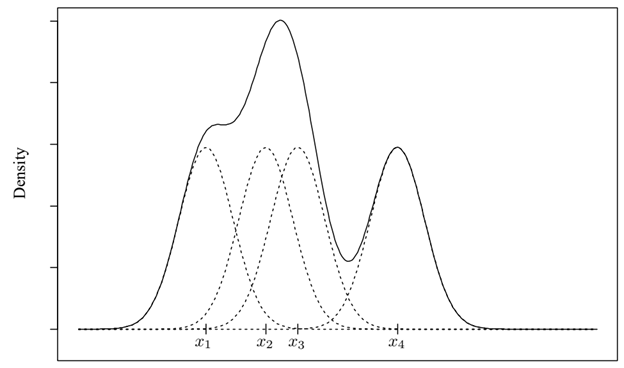

*Figure 6 The same Figure 10.1 used on p.328 of the Givens and Hoeting textbook that illustrates how the overall K.D.E. is calculated from individual kernels applied to each observation.*

The next step is to find a systematic way to choose the parameters of bandwidth and the kernel function. To do so in a systematic manner means that it’s important to look at these two values in terms of some sort of optimization process. Given these two parameters, the one that has the greater importance is the bandwidth. Below in Figure 7 is an example of different kernels on the left and different bandwidths on the right. Both graphs contain a histogram with $m=40$ bins. On the left the K.D.E. curves are created by the Uniform, Epanechnikov, and Triweight kernel functions with the Sheather-Jones bandwidth (the optimal bandwidth which is explained later). On the right the K.D.E. curves are created with the standard normal kernel and varying bandwidths of: $0.202281$ (Sheather-Jones), $1.5$, and $0.05$. It’s apparent that the bandwidths will have a much greater effect on how different the corresponding output is.


```
### Fig. 7
normal <- function(z) { # Normal kernel
  dnorm(z)
}

uniform <- function(z) { # Uniform kernel
  ifelse(abs(z) < 1, 1 / 2, 0)
}

epanechnikov <- function(z) { # Epanechnikov kernel
  ifelse(abs(z) < 1, (3 / 4) * (1 - z^2), 0)
}

triweight <- function(z) { # Triweight kernel
  ifelse(abs(z) < 1, (35 / 32) * ((1 - z^2)^3), 0)
}

# Silverman's rule of thumb
### The silverman function uses Silverman's rule of thumb
### for calculating the bandwidth.
silverman <- function(x) {
  n <- length(x)
  sigma_hat <- sd(x)
  h <- ((4 / (3 * n))^(1 / 5)) * sigma_hat
  return(h)
}
silverman_h <- silverman(x = f12)

# Sheather-Jones bandwidth using {locfit} package
sheather_jones_h <- locfit::sjpi(f12, silverman_h)[1]

# Terrell's maximal smoothing principle
### The maximal_smoothing_principle calculates the bandwidth
### using the method developed by Terrell that calculates
### the maximal smoothing principle.
maximal_smoothing_principle <- function(x) {
  n <- length(x)
  sigma_hat <- sd(x)
  R_K <- 1 / (2 * sqrt(pi))
  terrell_h <- 3 * ((R_K / (35 * n))^(1 / 5)) * sigma_hat
  return(terrell_h)
}

terrell_h <- maximal_smoothing_principle(x = f12)

### f_hat is the function that calculates the KDE estimate
### for a given x on the x-axis for a dataset, bandwidth,
### and kernel combination
f_hat <- function(x, X_i, h, K) {
  n <- length(X_i)
  (1 / h) * mean(K((x - X_i) / h))
}

f_hat_vec <- Vectorize(f_hat, vectorize.args = 'x') # Vectorize f_hat

par(mfrow = c(1,2)) # Compare kernels and bandwidths
# left-column: uniform, epanechnikov, triweight (m=40)
# right-column: normal (m=20, 40, 60) Silverman, Terrell, SJ
hist_est(var1 = f12, m = 40, # Plot a histogram (used twice)
  hist_tile = 'Histogram of log F12', hist_x_lab = 'log F12', line_color = 'gray')

# initialize variables for plotting
D <- range(f12); x_pts <- seq(D[1], D[2], length.out = 1e2)

f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # plot Uniform KDE

f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # plot Epanechnikov KDE

f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'black') # plot Triweight KDE

legend("topleft", legend = c('Uniform', 'Epanechnikov', 'Triweight'),
       lty = c(1,2,3), col = c('blue', 'red', 'black')) # add legend

f_hat_pts_sj <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = normal)
lines(x_pts, f_hat_pts_sj, lty = 1, col = 'blue') # add KDE
f_hat_pts_1.5 <- f_hat_vec(x = x_pts, X_i = f12, h = 1.5, K = normal)
lines(x_pts, f_hat_pts_1.5, lty = 2, col = 'red') # add KDE
f_hat_pts_0.05 <- f_hat_vec(x = x_pts, X_i = f12, h = 0.05, K = normal)
lines(x_pts, f_hat_pts_0.05, lty = 3, col = 'black') # add KDE
legend("topleft", legend = c('Sheather-Jones', '1.5', '0.05'),
       lty = c(1,2,3), col = c('blue', 'red', 'black'))
dev.off()
```

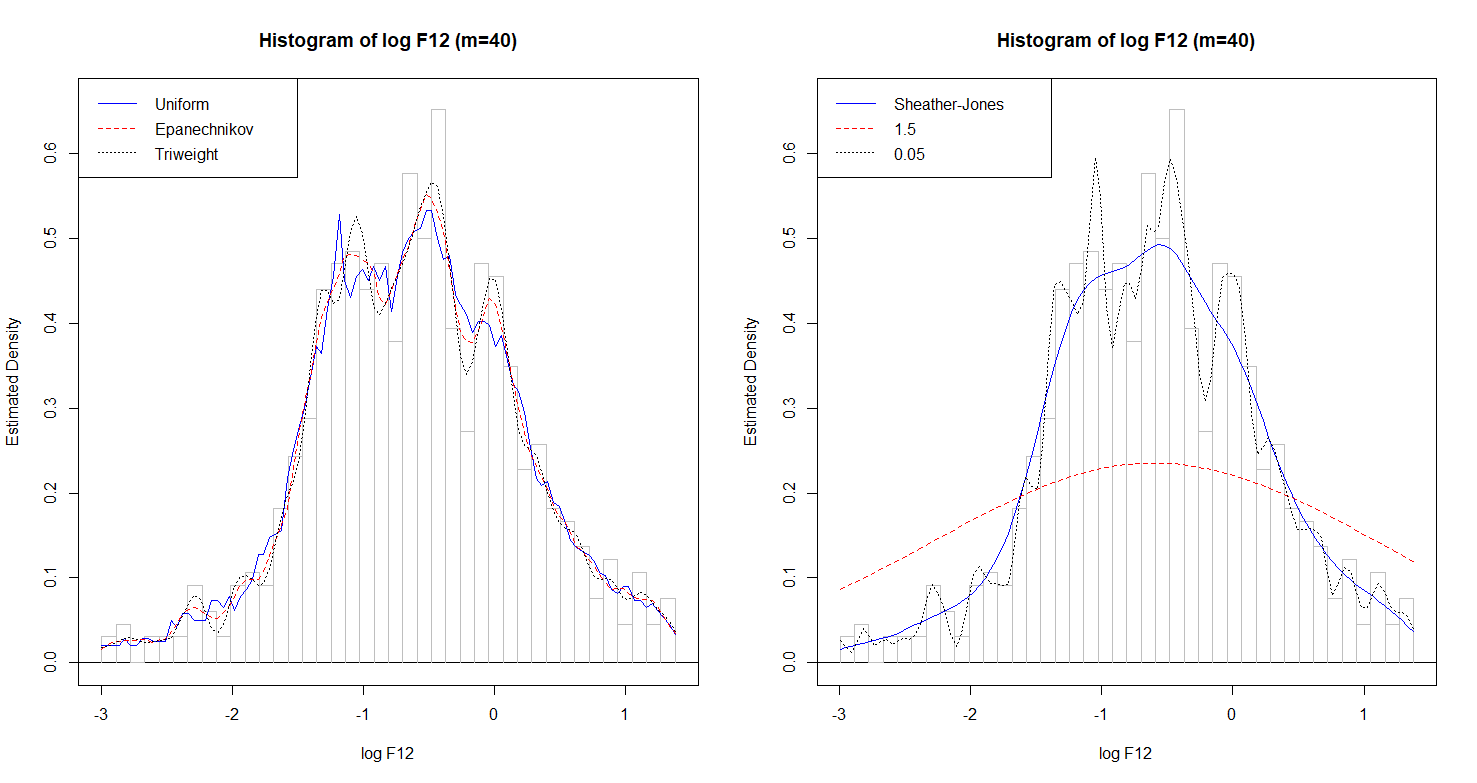

*Figure 7 The left plot shows a histogram ($m=40$) overlaid with three different kernels all with the same bandwidth (0.202281 from the Sheather-Jones fit). The right plot shows the same histogram with three K.D.E. curves from a Normal kernel and three different bandwidths (Sheather-Jones with 0.202281, 1.5, and 0.05).*

# 4.2.1 Optimal Bandwidth
<a id="ob"></a>
<a href="#top">Back to top</a>

To understand how the optimal bandwidth is chosen, it’s important to look back at the *integrated squared error* (ISE) (equation 5),

$$ISE(h) = \int_{-\infty}^{\infty}\left(\hat{f}(x) - f(x)\right)^2 dx.$$

This integrates the squared difference between the density estimate $\hat{f}(x)$ and the unknown true density $f(x)$ over all possible values. However, the true density $f(x)$ is unknown, so we can next look towards the *mean integrated squared error* (MISE) (equation 6),

$$MISE(h) = E{ISE(h)} = \int MSE_h \left(\hat{f}(x)\right)dx,$$

where $MSE_h \left( \hat{f}(x) \right) = E \left\{ \left( \hat{f}(x) - f(x) \right)^2 \right\} = var\left\{\hat{f}(x)\right\} + \left(bias\left\{\hat{f}(x)\right\}\right)^2$ (this is an algebraic trick where $E(\hat{f}(x))$ is added and subtracted into the equation and expanded to derive the variance and bias terms). Using the Taylor series expansion on the variance and bias terms, equation (6) can be rewritten as follows (equation 7),

$$MISE(h) = AMISE(h) + \mathcal{o}\left( \frac{1}{nh} + h^4 \right),$$

where (equation 8)

$$AMISE(h) = \frac{R(K)}{nh} + \frac{h^4 \sigma_K^4 R(f^{''})}{4}.$$

The $\mathcal{o}(\cdot)$ term is leftover from the Taylor series expansion and is an error term that is of less interest. In the goal of trying to find an optimum bandwidth, the term that we’re interested in is $AMISE(h)$. To minimize this term with respect to h, it can be shown that the optimum bandwidth can be expressed as (equation 9),

$$h = \left( \frac{R(K)}{n \sigma_K^4 R(f^{''})} \right)^{1/5}.$$

Another issue arises where to calculate this value, it requires that the true density $f(x)$ is known. Here $R(\cdot)$ is the roughness function which is defined as the inner product of a function (i.e., $\int g(z)^2 dz$).

# 4.2.1.1 Cross-Validation
<a id="cv"></a>
<a href="#top">Back to top</a>

In this section, two different cross-validation methods will be briefly introduced to show how good a density estimator is. An idea for choosing the proper bandwidth is to determine a quality function, $Q(h)$, that can see how good a density estimator $\hat{f}(x)$ is. Then the quality function is estimated with $\hat{Q}(h)$ and can be optimized to determine a possible bandwidth, $h$. The idea behind cross-validation isn’t unique to K.D.E. Given a set of data, many types of models can be built. However, the problem is in the logic of developing a model for prediction based on a set of data and using the same set of data to check how good the model’s fit is. The following is a cross-validation function for $\hat{f}(x)$ (equation 10)),

$$\hat{f}_{-i}(X_i) = \frac{1}{h(n-1)} \sum_{j \neq i} K \left( \frac{X_i - X_j}{h} \right).$$

The formula in equation (10) is like the original equation (3). The difference is that this time the input is not some value $x$ from the real number line but is one of the observations (the $i^{'}th$) from the dataset. The trick is that this same observation is excluded from the summation when the calculation is performed. A problem with this however is that the resulting $h$ that is estimated can vary greatly from sample to sample.

Given equation (10), the following *pseudo-likelihood* (PL) function will be expressed as (equation 11),

$$PL(h) = \prod_{i=1}^n \hat{f}_{-i}(X_i)$$

which can be thought of as a $\hat{Q}(h)$ that outputs a value based on the product of all the possible cross-validation terms. The resulting estimates for $h$ however tend to be too small (i.e., wiggly) and sensitive to the presence of outliers in the dataset.

The second cross-validation method uses an algebra trick to re-express equation (5) as follows (equation 12),

$$ISE(h) = R(\hat{f}) - 2E\left\{ \hat{f}(x) \right\} + R(F).$$

The last term is based on the true density and so it won’t vary from sample to sample. Therefore, it can be ignored for the purpose of finding $\hat{Q}(h)$. The *unbiased cross-validation* (UCV) formula can be written as (equation 13),

$$UCV(h) = R(\hat{f}) - \frac{2}{n} \sum_{i=1}^n \hat{f}_{-i} (X_i).$$

In equation (13), the middle term from equation (12) is estimated using the cross-validation function (equation (10)). The term on the left is the roughness of $\hat{f}(x)$ and will vary depending on the factors of what the chosen kernel function is and the chosen bandwidth. Some possibilities are to find an analytical (i.e., closed-form) solution to $R(\hat{f})$ if possible or to estimate it using something like Monte Carlo Integration. The goal of UCV is to determine the optimal bandwidth h by minimizing this value. The issue with this method is like the other in that the results depend heavily on the sample data that’s available. Instead of the value of $h$ being too small, they’re often too large (i.e., density is spread out, oversmoothing).

# 4.2.1.2 Plug-in Methods
<a id="pm"></a>
<a href="#top">Back to top</a>

An alternative to cross-validation is the use of a plug-in method. The optimal bandwidth technique that generalizes to different situations can be found here. A plug-in method implies that a default or pilot bandwidth value is used within the estimation process to derive a final bandwidth estimate. In the *Sheather-Jones method* (i.e., the best bandwidth estimator), a pilot bandwidth is used based on the *Silverman method*.

The Silverman method is based on equation (9), where the unknown value $R(f^{''})$ is replaced with $R(\phi^{''})/\hat{\sigma}^5$, where $\phi$ is the p.d.f. of the standard normal distribution and $\hat{\sigma}$ is the sample standard deviation. This leads to the following formula to estimate an optimal value for $h$ (equation 14),

$$h = \left(\frac{4}{3n}\right)^{1/5}\hat{\sigma}.$$

An advantage of this method is that it’s extremely easy to calculate. Problems arise however when the underlying data follows a multimodal distribution. The replacement for $R(f^{''})$ will lead to oversmoothing (i.e., $h$ too small). However, the resulting bandwidth is considered a suitable pilot bandwidth, $h_0$, and is to be calculated in the first stage of the Sheather-Jones method.

In the Sheather-Jones method, the idea is to estimate $R(f^{''})$ by using K.D.E. The idea is to instead replace this value with $R(\hat{f}^{''})$, where $\hat{f}^{''}$ is as follows (equation 15),

$$\hat{f}^{''}(x) = \frac{d^2}{dx^2} \left\{ \frac{1}{nh_0} \sum_{i=1}^n L \left( \frac{x-X_i}{h_0} \right) \right\} = \frac{1}{nh_0^3} \sum_{i=1}^n L^{''} \left( \frac{x-X_i}{h_0} \right).$$

In equation (15), the formula shows the second derivative of the K.D.E. function seen in equation (3). The differences are that a pilot bandwidth, $h_0$, substitutes $h$ and the kernel function $K(\cdot)$ is replaced with $L(\cdot)$ which is also a kernel function except that it requires that it is twice differentiable. Once the roughness, $R(\cdot)$, of this value is determined, it can be substituted back into equation (9) to find a final estimate of $h$, the Sheather-Jones estimate of the bandwidth.

Although the idea for the Sheather-Jones method is quite simple, the actual calculation can be quite difficult. To show how complex it is, the standard normal kernel will be selected for $L(\cdot)$. Let $L(\cdot)$ be the standard normal density, $\frac{exp⁡(-z^2/2)}{\sqrt{2\pi}}$, then $L^{''}(\cdot)$ is as follows:

(equation 16)

$$\frac{dL}{dz}=\frac{d}{dz} \frac{exp⁡(-z^2/2)}{\sqrt{2\pi}} = \frac{-1}{\sqrt{2\pi}}z \cdot exp⁡(-z^2/2)$$

(equation 17)

$$\frac{d^2 L}{dz^2} = \frac{d}{dz} \frac{-1}{\sqrt{2\pi}}z \cdot exp⁡(-z^2/2) = \cdots = \boxed{\frac{-1}{\sqrt{2\pi}} \cdot exp⁡(-z^2/2) (1 - z^2) = L^{''}(\cdot)}$$

Finding the result above is trivial, but the complexity will become more apparent soon. The next step is to calculate the roughness equation, $R(\hat{f}^{''})$:

(equation 18)

$$R(\hat{f}^{''}) = \int_{-\infty}^{\infty} \left[ \frac{1}{nh_0^3} \sum_{i=1}^n L^{''}\left( \frac{x-X_i}{h_0} \right) \right]^2 dx = \frac{1}{n^2h_0^6} \int_{-\infty}^{\infty} \left[ \sum_{i=1}^n L^{''}\left( \frac{x-X_i}{h_0} \right) \right]^2 dx$$

The next step is slightly more complicated since the formula is asking to find the square of a summation. This step can be explained as follows:

(equation 19)

$$\left[ \sum_{i=1}^nx_i \right]^2 = \sum_{i=1}^n x_i^2 + \sum_{\begin{array}{c} i,j=1 \\ i\neq j \end{array}}^nx_ix_j$$

Equation (19) is a reexpression of the same formula that's useful. There is another way to express this formula, but this one is simpler. To get a more intuitive understanding of equation (19), it’s possible to think of an $n\times n$ matrix where each $(i,j)$ element of the matrix is $x_i x_j$. By taking the product of each of these $x_i x_j$ elements together and then summing all these $n^2$ elements, then that is the result of equation (19). The left side represents the diagonal terms and the right side represents the upper and lower triangles of the matrix. Applying equation (19) to equation (18) leads to the following:

(equation 20)

$$R(\hat{f}^{''}) = \cdots = \frac{1}{n^2h_0^6} \int_{-\infty}^{\infty} \sum_{i=1}^n L^{''}\left( \frac{x-X_i}{h_0} \right)^2 + \sum_{\begin{array}{c} i,j=1 \\ i\neq j \end{array}}^n L^{''}\left( \frac{x-X_i}{h_0} \right) L^{''}\left( \frac{x-X_j}{h_0} \right) dx$$

Then plugging in the formula for $L^{''}(\cdot)$ derived in equation (17) leads to:

(equation 21)

$$= \frac{1}{n^2h_0^6} \int_{-\infty}^{\infty} \sum_{i=1}^n\left[ \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_i}{h_0} \right)^2}{2}\right) \left(1 - \left( \frac{x-X_i}{h_0} \right)^2 \right) \right]^2 + \\ \sum_{\begin{array}{c} i,j=1 \\ i\neq j \end{array}}^n \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_i}{h_0} \right)^2}{2}\right) \left(1 - \left( \frac{x-X_i}{h_0} \right)^2 \right) \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_j}{h_0} \right)^2}{2}\right) \left(1 - \left( \frac{x-X_j}{h_0} \right)^2 \right) dx $$

From here, the formula for equation (21) starts to become more complex. A possible solution for researchers is to utilize a computer package where the solution has already been computed for them and they only need to input the data along with possibly a pilot bandwidth, $h_0$. Another solution is to try and use Monte Carlo Integration to estimate this value. Monte Carlo Integration requires that equation (21) be transformed into an expectation $\text{w.r.t.}$ a Uniform distribution, where the bounds of the Uniform distribution correspond to the bounds of the integrand. When this is done, a constant equal to $\text{(upper bound-lower bound)}$ must be multiplied as a constant. However, a trick is that since the domain is ${\rm I\!R}$, instead a large value can be substituted such as $-10,000$ to $10,000$, since the idea is simply to approximate a useful result. There can still be problems with Monte Carlo Integration which will be shown later in the computational section.

The other alternative to utilizing a software package or Monte Carlo Integration is to find a closed-form solution. This is a much more difficult task than either steps so some ideas to how this can possibly be done with a standard normal kernel will be shown here. From a programming perspective, it could be more efficient to focus on just the portion of equation (21), where $\sum_{\begin{array}{c} i,j=1 \\ i\neq j \end{array}}^n (\cdot)$ . The reason is that from equation (19) the difference is that rather than taking the product of the $(i,j)$ terms, a function instead is being applied to the $(i,j)$ terms. In the case where $\sum_{i=1}^n (\cdot)$ , that is simply the diagonal of the matrix and so the $(i,j)$ terms are identical. In R, this can be replicated with the outer(X=…,Y=…,FUN=…) function, where the arguments to X and Y are the same dataset $\textbf{X}$ (i.e., a vector of values) and the argument to FUN is $\int L^{''}(\frac{x-X_j}{h_0})L^{''}(\frac{x-X_j}{h_0})$. This command will apply a function to all the $(i,j)$ elements of the matrix. Then, taking the sum of all these values would be equivalent to finding equation (20) (excluding the constant terms outside the integrand, $\frac{1}{n^2 h_0^6}$).

Next, we shall look closer at the formula that would be calculated for the outer() function in R. Below is the portion of interest, after the integrand has been distributed between the two terms:

(equation 22)

$$\Rightarrow \int_{-\infty}^{\infty} \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_i}{h_0} \right)^2}{2}\right) \left(1 - \left( \frac{x-X_i}{h_0} \right)^2 \right) \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_j}{h_0} \right)^2}{2}\right) \left(1 - \left( \frac{x-X_j}{h_0} \right)^2 \right) dx $$

Then simply rearranging the terms leads to the following.

(equation 23)

$$= \int_{-\infty}^{\infty} \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_i}{h_0} \right)^2}{2}\right) \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_j}{h_0} \right)^2}{2}\right) \left(1 - \left( \frac{x-X_i}{h_0} \right)^2 \right) \left(1 - \left( \frac{x-X_j}{h_0} \right)^2 \right) dx $$

As mentioned before, this is the formula that will be applied to all $(i,j)$ elements of $\textbf{X}$, and so the integrand can go inside the summation while the summation is ignored for the rest of the calculation. Recall, along the diagonal the $X_i$ and $X_j$ terms will be identical.

(equation 24)

$$= \int_{-\infty}^{\infty} \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_i}{h_0} \right)^2}{2}\right) \frac{-1}{\sqrt{2\pi}} exp⁡\left(-\frac{\left( \frac{x-X_j}{h_0} \right)^2}{2}\right) \underbrace{\left(1 - \left( \frac{x-X_i}{h_0} \right)^2 \right) \left(1 - \left( \frac{x-X_j}{h_0} \right)^2 \right)}_A dx $$

Let $A = \left(1 - \left( \frac{x-X_i}{h_0} \right)^2 \right) \left(1 - \left( \frac{x-X_j}{h_0} \right)^2 \right)$, so that the formula will be more compact. This will be calculated later.

(equation 25)
$$= \frac{1}{2\pi} \int_{-\infty}^{\infty} exp⁡\left(-\frac{\left( \frac{x-X_i}{h_0} \right)^2}{2}\right) exp⁡\left(-\frac{\left( \frac{x-X_j}{h_0} \right)^2}{2}\right) A dx $$

(equation 26)
$$= \frac{1}{2\pi} \int_{-\infty}^{\infty} exp⁡\left\{ -\frac{1}{2h_0^2} \left[ (x-x_i)^2 + (x-x_j)^2 \right] \right\} A dx $$

In equation (26), the two exponential terms were combined and the $X_i$, $X_j$ terms were changed to $x_i$, $x_j$ since they are going to be considered constants (i.e., from $\textbf{X}$) rather than random variables. Expanding the terms inside the exponential function and completing the square of the polynomial terms leads to the following:

(equation 27)
$$= \frac{1}{2\pi} \int_{-\infty}^{\infty} exp⁡\left\{ -\frac{1}{h_0^2} \left[ \left(x - \frac{x_i + x_j}{2}\right)^2 - \left(\frac{x_i + x_j}{2}\right)^2 \left(\frac{x_i^2 + x_j^2}{2}\right)^2 \right] \right\} A dx $$

(equation 28)
$$= \frac{1}{2\pi} \int_{-\infty}^{\infty} exp⁡\left\{ -\frac{1}{h_0^2} \left(x - \frac{x_i + x_j}{2}\right)^2 \right\} exp\left\{ \left(\frac{x_i^2 + x_j^2}{2} \right)^2 - \left(\frac{x_i + x_j}{2} \right)^2 \right\} A dx $$

(equation 29)
$$= \underbrace{\frac{1}{2\pi} exp\left\{ \left(\frac{x_i^2 + x_j^2}{2} \right)^2 - \left(\frac{x_i + x_j}{2} \right)^2 \right\}}_B \int_{-\infty}^{\infty} exp⁡\left\{ -\frac{1}{h_0^2} \left(x - \frac{x_i + x_j}{2}\right)^2 \right\} A dx $$

The term $B = \frac{1}{2\pi} exp\left\{ \left(\frac{x_i^2 + x_j^2}{2} \right)^2 - \left(\frac{x_i + x_j}{2} \right)^2 \right\}$ only contains constant terms so it can be pulled out of the integral. The following is a key trick to help when searching for a closed-form solution:

(equation 30)

$$= B \underbrace{\int_{-\infty}^{\infty} exp⁡\left\{ -\frac{1}{2 \left( \frac{h_0^2}{2} \right)} \left(x - \frac{x_i + x_j}{2}\right)^2 \right\} A dx}_C $$

Now, the equation looks much more like an expectation of $A$ $\text{w.r.t.}$ some function we can call $g(x)$, where $g(x) \sim Normal\left( \frac{x_i + x_j}{2}, \frac{h_0^2}{2} \right)$. We can try to understand this formula as follows:

(equation 31)
$$C^{'} = \frac{1}{\sqrt{2 \pi \frac{h_0^2}{2}}} \int_{-\infty}^{\infty} exp⁡\left\{ -\frac{1}{2 \left( \frac{h_0^2}{2} \right)} \left(x - \frac{x_i + x_j}{2}\right)^2 \right\} A dx$$

By solving for $C^{'}$, we can later multiply back the $\sqrt{2 \pi \frac{h_0^2}{2}}$ term to solve for $C$. The equation $C^{'}$ is essentially $E_g [A]=E_g [ax^4+bx^3+cx^2+dx+e]$, where $g$ is the normal distribution mentioned earlier. The difficult part is solving for this expectation, since $A$ is a polynomial of degree $4$. It could be possible to figure out those values by using the moment generating function (M.G.F.) for a normal distribution after splitting the formula into separate expected values (i.e., $E[X^t]$ for $t=1,\cdots,4$).

*Note: Wolfram Alpha was used to calculate the 4th degree polynomial and then the first four moments were input afterwards in the code shown later.*

The Givens and Hoeting textbook has another possibility on p.337 that shows what’s possible with a univariate kernel. It interestingly looks towards utilizing Newton’s method to find an optimal solution. Regardless, the Sheather-Jones method is said to be capable of performing well for a task while being comparatively simpler than other methods that can provide a bandwidth estimate that are of the same quality.


# 4.2.1.3 Maximal Smoothing Principle
<a id="msp"></a>
<a href="#top">Back to top</a>

The last method to be covered is called the maximal smoothing principle which is developed by Terrell. The trick in this method is to provide as conservative of an estimate as possible for $R(f^{''})$. This is a logical idea in that it gives an upper bound on how large the bandwidth could be for a given K.D.E. curve. Another bonus of Terrell’s method is that it’s extremely easy to calculate. The formula is as follows,

(equation 32)

$$h = 3 \left( \frac{R(K)}{35n} \right)^{1/5}\hat{\sigma}.$$

A related notion to finding the largest possible bandwidth is that it helps to prevent the K.D.E. curve from undersmoothing and acknowledging false modes in the density. However, this isn’t necessarily practical since the resulting K.D.E. curves are often too smooth. Yet, it can be helpful in giving researchers a guideline as to what the broadest view of what the true density could appear like (i.e., without focusing too much on false modes).

# 4.2.2 Optimal Kernel Function
<a id="okf"></a>
<a href="#top">Back to top</a>

Thus far the kernel function $K(\cdot)$ that has been examined the closest is the standard normal density. On the left-hand side graph of Figure 7 it shows three alternative kernel functions that have been briefly shown: Uniform, Epanechnikov, and Triweight. To understand a kernel function and its purpose, the following is a table some of the most common kernel functions that are used. Furthermore, the kernel functions are plotted below in Figure 8.

$$
\begin{array}{cc}
    \begin{array}{cc}
      \text{Kernel Name} & K(z) \\
      \text{Normal} & \frac{1}{\sqrt{2 \pi}} exp\left\{ -\frac{z^2}{2} \right\} \\
      \text{Uniform} & \frac{1}{2} \\
      \text{Epanechnikov} & \left( \frac{3}{4} \right) (1 - z^2) \\
      \text{Triangle} & 1 - |z| \\
      \text{Biweight} & \left( \frac{15}{16} \right) (1 - z^2)^2 \\
      \text{Triweight} & \left( \frac{35}{32} \right) (1 - z^2)^3 \\
    \end{array}
\end{array}
$$

```
### Fig. 8
triangle <- function(z) { # Triangle kernel
  ifelse(abs(z) < 1, 1 - abs(z), 0)
}

biweight <- function(z) { # Biweight kernel
  ifelse(abs(z) < 1, (15 / 16) * ((1 - z^2)^2), 0)
}

xs <- seq(-3, 3, length.out = 1e5) # Compare different kernel densities
plot(xs, uniform(xs), type = 'l', ylim = c(0,1.1),
     main = 'Kernel Functions', col = 'black',
     xlab = latex2exp::TeX('z'), ylab = latex2exp::TeX('K(z)'))
lines(xs, normal(xs), lty = 2, col = 'red')
lines(xs, epanechnikov(xs), lty = 3, col = 'green')
lines(xs, triangle(xs), lty = 4, col = 'blue')
lines(xs, biweight(xs), lty = 5, col = 16)
lines(xs, triweight(xs), lty = 6, col = 'purple')
legend("topleft", legend = c('Uniform', 'Normal', 'Epanechnikov',
                             'Triangle', 'Biweght', 'Triweight'),
       lty = c(1:6), col = c('black', 'red', 'green', 'blue', 16, 'purple'))
dev.off()
```

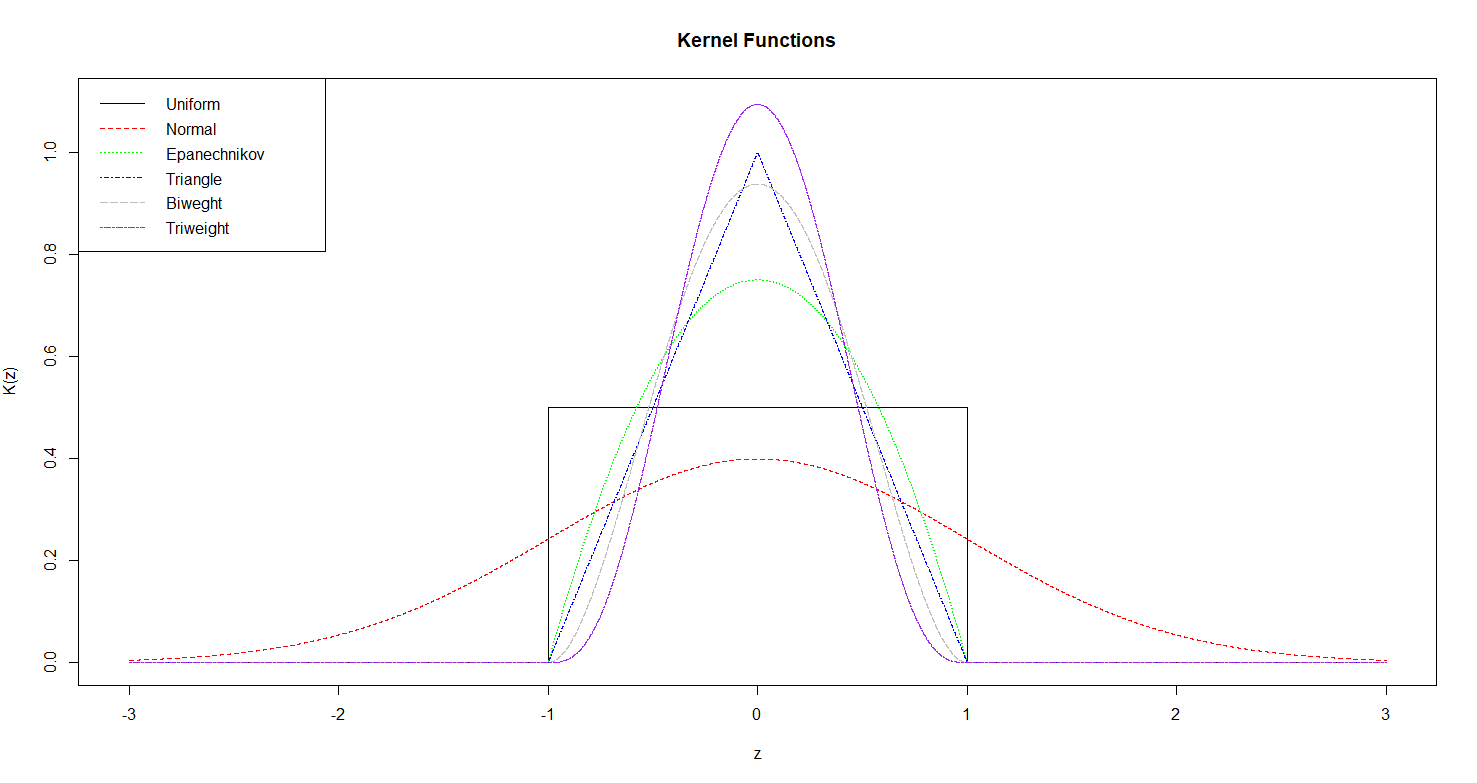

*Figure 8 Plot showing the different kernel functions.*

These kernels functions are all centered around $0$ and symmetric. This is logical given that each of data points along the $x$-axis after having applied a kernel function will have an output that is likewise symmetric and centered about the location of each data point. Looking back at Figure 6, for example if the kernel function were the Uniform kernel, they would all instead have a square shape and the corresponding overall K.D.E. curve would appear somewhat different.

Looking at the graph of the different kernel functions in Figure 8, it’s apparent that the domain of each the kernel functions are alike except for the Normal kernel (previously referred to as the standard normal kernel). What’s happening is that for example the Epanechnikov kernel would be fully written as follows,

(equation 33)
$$Epanechnikov(z) = \left\{
\begin{array}{cc}
  & 
    \begin{array}{cc}
      \left(\frac{3}{4}\right) (1-z^2) & \text{if } \left|z\right| < 1 \\
      0 & \text{otherwise}
    \end{array}
\end{array} \right.
$$

This constrains each of the other kernels so that they only include a neighborhood of points are included into the total calculation. The constraint occurs when in equation (3), only a subset of the data points $\sum_{i=1}^n K\left( \frac{x-X_i}{h} \right)$ are summed since those where $\left|\frac{x-X_i}{h}\right|\geq1$ contribute only a value of $0$. A difference between this kernel function and something like the Normal kernel is that this one is designed specifically for K.D.E. where it has certain theoretical properties that make it suitable for the task.

An idea when selecting kernel functions is simply to try them all. All the kernel functions mentioned are roughly close in terms of how good they are. Given a dataset where there’s an interest in implementing K.D.E., it’s reasonable to simply try applying each of the kernels to see if any of them work best. However, the results will likely show that most of them aren’t too different. By looking at the different kernels in Figure 8, it’s not too surprising why this is the case.

An important note however is that when testing different kernels, a bandwidth that is found to be best for one kernel won’t necessarily have the same effect on another kernel. This brings into attention the concept of rescaling bandwidths from kernel to kernel. Given two kernels, $K(\cdot)$ and $L(\cdot)$, with corresponding bandwidths $h_K$ and $h_L$, the following is a formula to determine the appropriate bandwidth for another kernel function if one has already been determined,

(equation 34)

$$\frac{h_K}{h_L} = \frac{\delta ( K )}{\delta (L)},$$

where $\delta (K)=\left(R(K)/\sigma_K^4\right)^{1/5}$ for any kernel function (regardless of $K$, $L$, or some other kernel function). Equation (4) makes it possible to compare to kernels and some bandwidth that provides a likewise level of smoothing.
	Below in Figure 9, the effect of scaling the bandwidths can be seen more clearly. The graph on the left-hand side shows the same left-hand side graph in Figure 7 where it was shown how kernels have less of an influence compared to the bandwidth. On the right-hand side graph, each of the bandwidths that are input into the three kernel functions have first been scaled from the original Sheather-Jones bandwidth derived for a Normal kernel. In order of Uniform, Epanechnikov, and Triweight, the bandwidths have changed to $0.3519823$, $0.4478129$, and $0.6024174$ from an original $0.2022821$. It’s evident now that the smoothing much more closely matches the original level of smoothing determined from the Normal kernel. In the right-hand graph, the K.D.E. curve from the Normal kernel is also shown for context. Looking closely, it’s apparent that they are all quite alike.



```
### Fig. 9
### The scale_bandwidth() function will scale the bandwidth
### for one kernel and bandwidth combination (K) to another
### kernel and bandwidth combination (L).
scale_bandwidth <- function(h_K, delta_K, delta_L) {
  h_L <- (h_K / delta_K) * delta_L
  return(h_L)
}

# delta(K) values for bandwidth scaling
delta_normal <- (1 / (2 * sqrt(pi)))^(1 / 5)
delta_uniform <- (9 / 2)^(1 / 5)
delta_epanechnikov <- 15^(1 / 5)
delta_triangle <- 24^(1 / 5)
delta_biweight <- 35^(1/ 5)
delta_triweight <- (9450 / 143)^(1 / 5)

delta_vec <- c(delta_uniform, delta_epanechnikov, # vector for delta(K)
               delta_triangle, delta_biweight, delta_triweight)
# scale according to Normal kernel and Sheather-Jones bandwidth
scale_vec <- sapply(delta_vec, function(x)
  scale_bandwidth(h_K = sheather_jones_h,
                  delta_K = delta_normal, delta_L = x))

par(mfrow = c(1,2)) # Show the fit for different kernels
hist_est(var1 = f12, m = 40, # Plot a histogram (used twice)
         hist_tile = 'Histogram of log F12', hist_x_lab = 'log F12', line_color = 'gray')
# Left-hand side graph
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'black') # add KDE
legend("topleft", legend = c('Uniform', 'Epanechnikov', 'Triweight'),
       lty = c(1,2,3), col = c('blue', 'red', 'black'))

# Right-hand side graph
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 2) # add KDE
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = f12, h = scale_vec[1], K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = f12, h = scale_vec[2], K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = f12, h = scale_vec[5], K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'purple') # add KDE
legend("topleft", legend = c('Normal','Uniform', 'Epanechnikov', 'Triweight'),
       lty = c(1,1,2,3), lwd = c(2,1,1,1), col = c('black', 'blue', 'red', 'purple'))
dev.off()
```

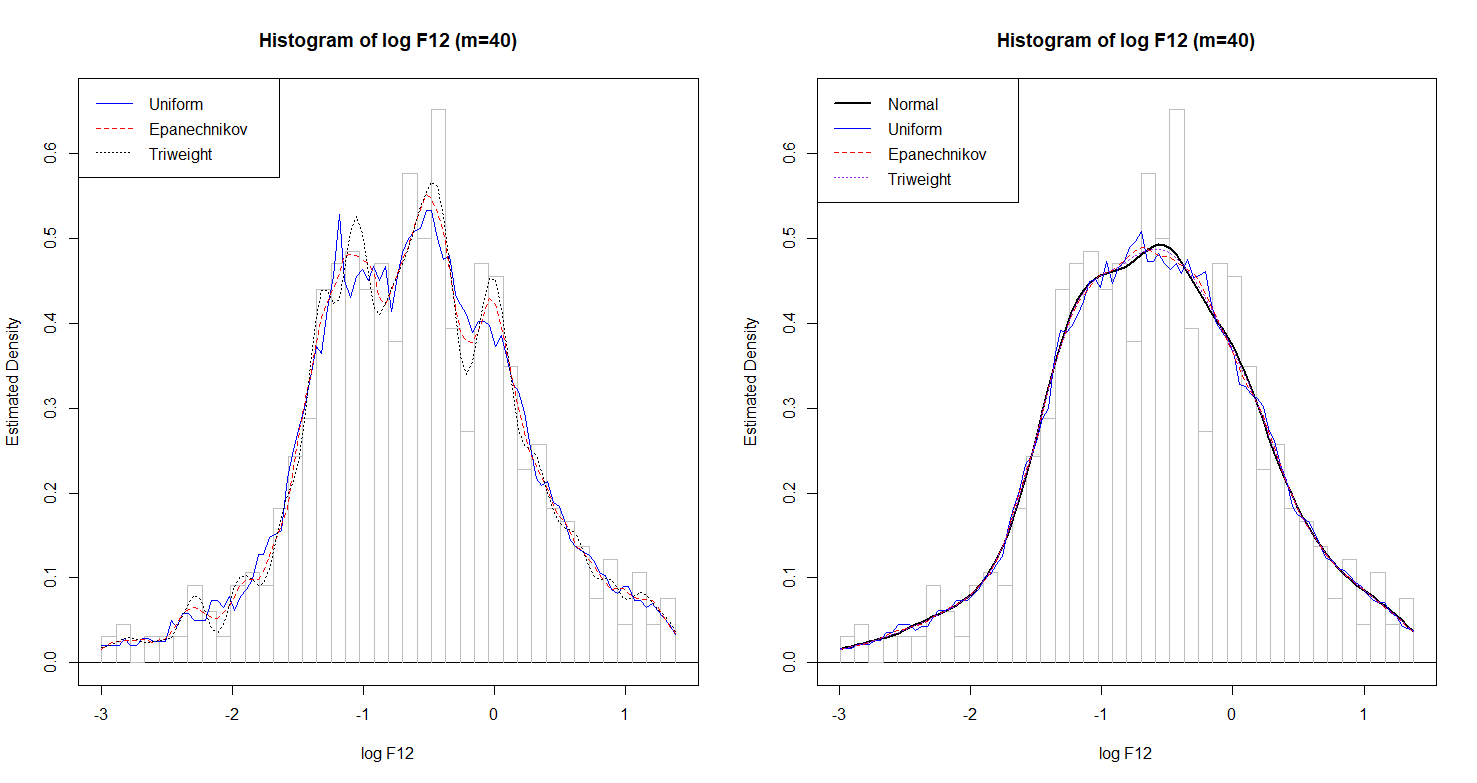

*Figure 9 The graph on the left-hand side is the same as the left-hand side graph of Figure 7. On the right-hand side is the same graph except that the bandwidths have been scaled to match the original Sheather-Jones bandwidth from a Normal kernel.*

# 5.	Notable Applications
<a id="na"></a>
<a href="#top">Back to top</a>

At this point it may seem like K.D.E. is just an alternative to traditional histograms that are slightly more complicated to implement. The idea in this section is to show the audience that K.D.E. can have truly profound impacts for researchers where they may discover new findings that have sprung from using this form of exploratory data analysis. This notion that K.D.E. can lead to breakthroughs isn’t necessarily obvious at first. The reason is that K.D.E. is simply analyzing what is comparable to the histogram of a variable within a dataset. The only difference is that the nature of histograms makes it possible for researchers to not notice subtle traits that once witnessed by researchers can lead to breakthroughs upon further investigation of a variable. In this section, three different applications will be presented. Since in these applications data wasn’t readily available, graphs from the research papers will be presented to show their results. The first two applications come from Silverman’s (1986) research paper where in the introduction some important industry applications were shown. The last application comes from a more modern application of K.D.E. for the purpose of object detection in videos.

Below in Figure 10 it shows the plot of two different K.D.E. curves on a single plot. In Silverman’s (1986) paper he mentions a profound application of K.D.E. explained in a paper by Emery and Carpenter (1974). The solid curve (A) and the dotted curve (B) show two different samples that were plotted together. Group A consists of babies that have passed away from sudden infant death syndrome and their degranulated cell mast counts (after some transformation of the data e.g., natural logarithm). Group B consists of babies that have passed away due to other causes that don’t directly affect this variable. Having seen the distinction in this variable for the two groups, further investigation can be made based on these findings. Within the published article by the researchers, it was noted that finding this discovery means that infants that are born with this trait are in a high-risk group for this disease.

![Fig 10](https://i.imgur.com/QuZoj91.jpg)

*Figure 10 From Silverman’s (1986) paper that references a study by Emery and Carpenter (1974). The graph shows an overlay of the K.D.E. for two different groups of infants and their granulated mast cell count (after transformation).*

Another application from Silverman’s (1986) paper can be seen below in Figure 11. In this graph, a steel surface is being measured at roughly 15,000 different points. The density shows the height of the steel surface above some arbitrarily chosen height. The graph comes from a research paper by Bowyer (1980) where the importance of this discovery is relevant for engineering applications. Looking at the graph, it’s apparent that there’s a slight skew to the curve, contradicting previous notions that the density would follow a Gaussian (a.k.a. normal) distribution. This subtle difference is important since having the density to the left implies problems related to fatigue in the steel, while density to the right implies problems related to where the steel would be contacting other surfaces. Another paper by Adler and Firman (1981) further explores suitable fixes to this apparent skew in the distribution.

![Fig 11](https://i.imgur.com/hHn9baS.jpg)

*Figure 11 From Silverman’s (1986) paper that references a study by Bowyer (1980). The graph shows the K.D.E. of the height in microns that a steel surface is above an arbitrary height.*

A more modern application of K.D.E. can be seen below in Figure 12. The application comes from a paper by Elgammal, et. al. (2002) that has been cited 1,946 times. The purpose is to create background and foreground modeling from surveillance cameras that can help to distinguish objects of interest from the background scenes. In Figure 12 is an example of background subtraction from the research paper. The upper image labeled (a) is the original image and the lower image labeled (b) is the image after applying K.D.E. to help distinguish the background from objects of interest. The methodology is to apply each of the pixels as a vector to a K.D.E. function, where each pixel has a varying level of intensity. After applying the kernel, a second step is to classify pixels as either foreground or background based upon some threshold level. The technique seems to do a great job of distinguishing a faint object from the background scenes in the figure. Within the research paper, further techniques are explored such as: non-kernel techniques, videos that have color, and managing false positives amongst other concepts. The work done in this research paper has important uses related to different problems within the field of video surveillance such as: detecting unusual motion, tracking targets, labeling body parts, and understanding how different people are interacting. It’s also worth noting that this is one of the exceptions where K.D.E. isn’t for exploratory data analysis, but instead a function of some alternate application.

![Fig 12](https://i.imgur.com/A3SLQZ1.jpg)

*Figure 12 The upper image shows the original image (a). The lower image (b) shows the same image after K.D.E. is applied to the pixels and a threshold is applied to identify the foreground and subtract the background.*

# Computational Piece

# 1. Pipeline
<a id="pipeline"></a>
<a href="#top">Back to top</a>

In this section the focus is to apply the concepts previously discussed and to show their usefulness on a given dataset. An issue with trying to replicate results from the above-mentioned notable applications is that the first two are relatively old research papers and data for them isn’t easy to come by. Regarding the last paper, the application is quite complex and so the implementation of K.D.E. in that context is beyond the focus of this project. Therefore, to show the usefulness of K.D.E. from a computational aspect, the idea in this section is to develop a pipeline that flows through the different concepts related to choosing the parameters of bandwidth and kernel function.

The idea is to accomplish the following in a ‘pipeline’ format:
1.	Determine a suitable number of bins for a starting histogram.
2.	Find the results from cross-validation methods: pseudo-likelihood, UCV just to explore the results.
3.	Use the Silverman method to determine a pilot bandwidth for the Sheather-Jones bandwidth. The kernel function in this situation will be the Normal kernel.
4.	Find the bandwidth corresponding with Terrell’s maximal smoothing principle.
5.	By using bandwidth scaling, find the corresponding bandwidths for the three bandwidths mentioned for each of the other previously shown kernel functions (e.g., Uniform, Epanechnikov, etc.).
6.	Compare the results across bandwidths and kernels on the chosen histogram.
7.	Determine a suitable bandwidth and kernel function combination for a variable.

The meaning of ‘pipeline’ in this case is to minimize the coding as much as possible by creating functions in R that will streamline the process in as simple as possible terms. However, there is of course the limitation that certain steps require that a researcher look carefully at the results before further decisions are made.


# 2. Dataset 1 (Diabetes)
<a id="d1"></a>
<a href="#top">Back to top</a>

The first dataset to be examined comes from the UCI Machine Learning database, but it was downloaded from the website Kaggle. According to the description, this dataset is for the purposes of predicting whether patients have diabetes based on other variables in the dataset. The data comes from the National Institute of Diabetes and Digestive and Kidney Diseases. The observations in the dataset are records of females with a Pima Indian heritage and variables such as: blood pressure, insulin levels, body mass index, etc. It’s possible to explore all nine variables (including the indicator variable for whether they have diabetes), but for the purpose of this presentation only one will be explored in detail.

Below in Figure 13 is a grid of the default histograms and K.D.E. curves for each of the variables in the dataset. A more thorough and perhaps the ideal methodology would be to analyze each of the variables carefully, going through the process of picking a suitable number of histogram bins and fitting a pair of kernel functions and bandwidths. In this case, since only one variable will be fully explored, the idea was to search for a variable that seems like it’d benefit from K.D.E. In other words, a variable whose histogram and K.D.E. combination seem to imply that an apparently typical distribution in truth has subtle characteristics that could be of interest to researchers.

```
### Computational Piece
### Dataset 1: Diabetes
diabetes <- read.csv('diabetes.csv') # Load data

### Fig. 13
par(mfrow = c(3,3)) # Plot all the variables find ones that maybe worth investigating
var_description <- c( # Variable descriptions
  'Number of times pregnant',
  'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
  'Diastolic blood pressure (mm Hg)',
  'Triceps skin fold thickness (mm)',
  '2-Hour serum insulin (mu U/ml)',
  'Body mass index (weight in kg/(height in m)^2)',
  'Diabetes pedigree function',
  'Age (years)',
  'Class variable (0 or 1)'
)
for (i in 1:ncol(diabetes)) { # Plot grid of 9 variables
  hist(diabetes[,i], freq = FALSE,
       main = paste0('Histogram of ', colnames(diabetes)[i]),
       xlab = var_description[i])
  lines(density(diabetes[,i]))
}
dev.off()
```

![Fig 13](https://i.imgur.com/wOX1GeQ.jpg)

*Figure 13 Grid of default histograms and K.D.E. curves generated in RStudio for all nine variables in the diabetes dataset.*

```
### Fig. 16
### The UCV function calculates the unbiased cross-validation
### value for a variable given a bandwidth. It calculates the
### roughness of f-hat using a closed-form solution along with
### the expectation of f-hat using cross-validation to derive
### the final result.
UCV <- function(x, h = sheather_jones_age) {
  # First calculate R(f-hat)
  n <- length(x)

  upper_lower_triangle <- outer(X = x, Y = x, FUN = function(u, v) {
    exp((-1 / (4 * (h^2))) * ((u - v)^2))
  }) # apply f(u,v) to all elements of n*n matrix

  R_f <- (1 / ((n^2) * (h^2))) * # R(f-hat)
    ((h * sqrt(pi)) / (2 * pi)) * sum(upper_lower_triangle)
  
  # Calculate the 2*E[f-hat] term using cross-validation and combine with R_f
  ucv <- R_f - 2 * mean(cross_validation(var1 = x, h = h, K = normal))

  return(ucv)
}

# test values about S-J
ucv_seq_age <- seq(sheather_jones_age - 2, sheather_jones_age + 3, length.out = 20)
ucv_values_age <- sapply(ucv_seq_age, function(x) {
  UCV(x = diabetes$Age, h = x)
})

# optimal UCV bandwidth
ucv_h_age <- ucv_seq_age[which.min(ucv_values_age)] # 0.1990868
ucv_values_age[which.min(ucv_values_age)] # -0.1012167

par(mfrow = c(1,2)) # Plot UCV error and UCV histogram
plot(ucv_seq_age, ucv_values_age, type = 'l', # plot UCV results
     main = 'UCV vs. Bandwidth', xlab = 'Bandwidth h', ylab = 'UCV')
hist_est(var1 = diabetes$Age, m = 32,
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
D <- range(diabetes$Age); x_pts <- seq(D[1], D[2], length.out = 1e2)
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age, h = ucv_h_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'red', lwd = 1) # add KDE
legend("topright", legend = c('UCV'), col = 'red', lty = 1)
dev.off()
```

## 1. Determine a suitable number of bins for a starting histogram.
The chosen variable is the Age of the observation. This variable indicates the age in years of the patient. Below in Figure 14 is a side-by-side of the default histogram and K.D.E. curve on the left-hand side (i.e., using hist() and density() in R) and a custom histogram that has $m=32$ bins (while still using the default K.D.E. in R). The methodology in choosing the number of bins was to plot $9\times 9$ grids of histograms of varying numbers of bins to see which ones seemed to suit this variable the best. Factors for determining whether the number of bins is suitable for a histogram include: the bins followed well the general curve of the K.D.E., there are no spaces between bins, no random shapes due to a certain bin interval containing a spike in number of cases, etc. In truth, there’s no correct answer and so it’s up to the researcher to determine which number of bins are suitable and which poorly represent the underlying distribution. To be fair, it’s possible for several different number of bins to be equally suitable for the histogram. Furthermore, it’s possible that some “irregular” histograms are also worth investigating, because of the possibility that they uncover hidden characteristics that other histograms may overlook. In this case, with 32 bins, the histogram seemed to fit well enough to the K.D.E. curve without appearing to exaggerate abnormal features.

```
### Age variable
par(mfrow = c(3,3)) # Try different 'm' bins
m_vec <- round(seq(25, 40, length.out = 9))
sapply(m_vec, function(x) { # Test different ranges for 'm'
  hist_est(var1 = diabetes$Age, m = x,
           hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
  lines(density(diabetes$Age))
})
dev.off()

### Fig. 14
par(mfrow = c(1,2)) # Compare chosen bins with default
hist(diabetes$Age, main = 'Default Histogram for Age',
     xlab = 'Age (years)', freq = FALSE)
lines(density(diabetes$Age))
hist_est(var1 = diabetes$Age, m = 32,
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
lines(density(diabetes$Age))
dev.off()
```

![Fig 14](https://i.imgur.com/sY29PzR.jpg)

*Figure 14 On the left-hand side is the default histogram and on the right-hand side is a custom histogram with 32 bins. The same default K.D.E. curve is used on both graphs.*

## 2. Find the results from cross-validation methods: pseudo-likelihood, UCV just to explore the results.
The next step is to analyze some bandwidths by using the methods of cross-validation. The two cross-validation methods are pseudo-likelihood and unbiased cross-validation (UCV). In this case, both fail to work properly, given that the code is correct. The method in this case was to first develop a cross-validation function since this same calculation is required for both methods.

In the first case with pseudo-likelihood, the result was that R would fail to give a useful result since the output would become $0$. The pseudo-likelihood method requires that the product of all $n$ cross-validation results (i.e., $\hat{f}_{-i}(X_i)$) be multiplied together. In this case, each of the individual cross-validation results were decimal values between $0$ and $1$. With over $700$ observations, the product of them together is too small and so R simply outputs $0$. This occurred with a wide range of different bandwidths that were tested. The result can be seen below in Figure 15.


```
### Cross-Validation
### Fig. 15
# Calculate the Silverman and Sheather-Jones bandwidths for test
# bandwidths in cross-validation.
silverman_age <- silverman(x = diabetes$Age)
sheather_jones_age <- locfit::sjpi(x = diabetes$Age, a = silverman_age)[1]

### The cross_validation function calculates the cross-validation values
### for each of the observations in a variable. It returns a matrix
### of each of the cross-validation values.
cross_validation <- function(var1 = diabetes$Age, h = 0.3, K = normal) {
  n <- length(var1)
  i_not_j_vec <- 1:n
  cv_matrix <- matrix(NA, nrow = length(var1))
  K_i_not_j <- matrix(NA, nrow = length(var1))
  
  for (i in 1:n) {
    for (j in i_not_j_vec[-i]) {
      K_i_not_j[j] <- K((var1[i] - var1[j]) / h)
    }
    cv_matrix[i] <- (1 / (h * (n - 1))) * sum(K_i_not_j[,1], na.rm = TRUE)
    K_i_not_j <- matrix(NA, nrow = length(var1)) # reset to NA's
  }
  return(cv_matrix)
}

h_seq_age <- seq(sheather_jones_age - 2, # Test bandwidths for pseudo-likelihood
                 sheather_jones_age + 2, length.out = 1e2)

# Calculate and plot pseudo-likelihood values
pseudo_likelihood_age <- sapply(h_seq_age, function(x) {
  cv_output <- cross_validation(var1 = diabetes$Age,
                                h = sheather_jones_age, K = normal)
  prod(cv_output) # take the product of all the C-V values
})

plot(h_seq_age, pseudo_likelihood_age, type = 'l', # Plot the pseudo-likelihood
     main = 'Pseudo-likelihood vs Bandwidth',
     xlab = 'Bandwidth h', ylab = 'pseudo-likelihood')
dev.off()
```

![Fig 15](https://i.imgur.com/a84gF7N.jpg)

*Figure 15 Plot of pseudo-likelihood vs bandwidth showing how the resulting values are all 0 throughout the tested bandwidths.*

In the other case with UCV, a closed-form solution was found for $R(\hat{f})$ since it wasn’t too complicated to calculate. An approach like what was used to show the steps for understanding $R(\hat{f}^{''})$ were used (equation (20)). The methodology was to first develop a function that could calculate the UCV for a single bandwidth, vectorize it, and then try it with a series of different bandwidths. Below in Figure 16 on the left-hand side, the tested bandwidths and their corresponding UCV values can be seen. It’s apparent that the UCV is minimized near to $0$. Out of the tested bandwidths, the minimum UCV is $-0.1012167$ which comes from a bandwidth of $0.1990868$. Looking at the graph, it seems that the UCV is minimized around this bandwidth before spiking to the left and slowly increasing towards the right. On the right-hand side of Figure 16 is histogram with a K.D.E. created by the Normal kernel and the UCV bandwidth. The K.D.E. is extremely spikey and seems to be a poor fit. Despite being able to emphasize the hump around $40$ years of age, it’s not a good overall fit. The results are somewhat surprising in that the UCV is known to oversmooth the data, but in this situation undersmoothing occurs.

As a note, in both cases, Silverman’s method and Sheather-Jones method (using the {locfit} package) were first calculated to find a general idea of what a suitable bandwidth could be for the problem. Then from these starting bandwidths, different bandwidths within a range (e.g., $\pm 2$ ) were tried. Furthermore, bandwidths that are negative don’t make sense since there can’t be a negative length, and bandwidths that are too large don’t produce useful K.D.E.’s.

```
### Fig. 16
### The UCV function calculates the unbiased cross-validation
### value for a variable given a bandwidth. It calculates the
### roughness of f-hat using a closed-form solution along with
### the expectation of f-hat using cross-validation to derive
### the final result.
UCV <- function(x, h = sheather_jones_age) {
  # First calculate R(f-hat)
  n <- length(x)

  upper_lower_triangle <- outer(X = x, Y = x, FUN = function(u, v) {
    exp((-1 / (4 * (h^2))) * ((u - v)^2))
  }) # apply f(u,v) to all elements of n*n matrix

  R_f <- (1 / ((n^2) * (h^2))) * # R(f-hat)
    ((h * sqrt(pi)) / (2 * pi)) * sum(upper_lower_triangle)
  
  # Calculate the 2*E[f-hat] term using cross-validation and combine with R_f
  ucv <- R_f - 2 * mean(cross_validation(var1 = x, h = h, K = normal))

  return(ucv)
}

# test values about S-J
ucv_seq_age <- seq(sheather_jones_age - 2, sheather_jones_age + 3, length.out = 20)
ucv_values_age <- sapply(ucv_seq_age, function(x) {
  UCV(x = diabetes$Age, h = x)
})

# optimal UCV bandwidth
ucv_h_age <- ucv_seq_age[which.min(ucv_values_age)] # 0.1990868
ucv_values_age[which.min(ucv_values_age)] # -0.1012167

par(mfrow = c(1,2)) # Plot UCV error and UCV histogram
plot(ucv_seq_age, ucv_values_age, type = 'l', # plot UCV results
     main = 'UCV vs. Bandwidth', xlab = 'Bandwidth h', ylab = 'UCV')
hist_est(var1 = diabetes$Age, m = 32,
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
D <- range(diabetes$Age); x_pts <- seq(D[1], D[2], length.out = 1e2)
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age, h = ucv_h_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'red', lwd = 1) # add KDE
legend("topright", legend = c('UCV'), col = 'red', lty = 1)
dev.off()
```

![Fig 16](https://i.imgur.com/hyyBDwM.jpg)

*Figure 16 On the left is a plot showing UCV against bandwidth for the Age variable from the diabetes dataset. It’s apparent that the value of UCV is minimized around 0. On the right is the corresponding K.D.E. for the UCV bandwidth and the normal kernel.*

## 3. Use the Silverman method to determine a pilot bandwidth for the Sheather-Jones bandwidth. The kernel function in this situation will be the Normal kernel.

Previously it was mentioned that the bandwidths for the Silverman method and Sheather-Jones method had already been calculated for the purpose of having a starting bandwidth in the cross-validation methods. The Silverman bandwidth is a simple calculation and is shown below. The Sheather-Jones method is more complicated and requires the Silverman bandwidth for a pilot bandwidth in the estimation process. Both the default {stats} and {MASS} packages in RStudio have functions to calculate the value. However, they both can generate varying results and so their usefulness is not certain. A third package called {locfit} was used to examine the output for the Sheather-Jones estimate. The bonus of {locfit} is that it allows for users to input a single bandwidth as the pilot bandwidth whereas the other two packages ask for a range of possible values. In this case, the others were left to default settings while the Silverman bandwidth was used for the argument to {locfit}'s function.

Additionally, Monte Carlo Integration was used to try and approximate the Sheather-Jones bandwidth. Due to the infinite bounds of the initial integrand, approximation was used so that the bounds were changed to $\pm 10,000$. Furthermore, $1,000$ randomly sampled values from a $Uniform[-10,000,10,000]$ distribution was used in the process of Monte Carlo Integration. To briefly explain how Monte Carlo Integration works, the idea is to approximate a difficult to derive integral by changing it from an integrant to an expectation $w.r.t.$ a Uniform distribution. This can be seen below:

$$I = \int_a^b h(x) dx \rightarrow \int_a^b (b-a)h(x)\frac{1}{b-a}dx \rightarrow E_f[g(x)]$$

where $g(x) = (b-a)h(x)$ and $f(x) = \frac{1}{b-a} \sim Uniform[a,b]$ Then, approximate $I$ with $\hat{I}$,

$$\hat{I} = \frac{1}{n} \sum_{i=1}^n g(x_i),$$

where $X \sim Uniform[a,b]$ The problem? $a=-\infty$ and $b=\infty$ Then approximate with $a=−10,000$ and $b=10,000$.

Lastly, the closed-form solution was also calculated. This ideally is the best possible result, given that the calculations are correct. The reason is that it's the most precise and it's known exactly what formula is being used to calculate the answer.

$$
\begin{array}{cccccc}
  & 
    \begin{array}{cccccc}
      \text{Silverman} & \text{\{stats\}} & \text{\{MASS\}} & \text{\{locfit\}} & \text{Monte Carlo} & \text{closed-form} \\
      3.298613 & 1.007274 & 4.029095 & 1.672771 & 1.515068 & 1.673207 \\
    \end{array}
\end{array}
$$

The results are close, except for the {MASS} package which has a larger estimate (ignoring the Silverman bandwidth). It's somewhat surprising how similar the closed-form solution is to the {locfit} solution. A possibility is that they only differentiate through some rounding process. For the purpose of this presentation, only the result using the closed-form solution will be utilized. Also, as mentioned the kernel function utilized to derive the results is the Normal kernel function. This is a rather standard kernel that is widely used and so there shouldn’t be an issue with implementing it in this case.

## 4. Find the bandwidth corresponding with Terrell’s maximal smoothing principle.
The bandwidth for the maximal smoothing principle by Terrell is a simple calculation like how Silverman’s method is also easy to calculate. In this case, the resulting bandwidth is $3.562298$. It can be seen at this point that Terrell’s bandwidth is the largest, Silverman’s is in the middle, and Sheather-Jones is the smallest. This is the expected result as the first two tend to oversmooth by design while the last case tends to provide the most appropriate fit.


## 5. By using bandwidth scaling, find the corresponding bandwidths for the three bandwidths mentioned for each of the other previously shown kernel functions (e.g., Uniform, Epanechnikov, etc.).
The chosen bandwidth to base the scaling upon is the Sheather-Jones bandwidth derived using the closed-form approximation with the Normal kernel function (i.e., $1.673207$). Therefore, the scaling will require that bandwidths for the Uniform, Epanechnikov, Triangle, Biweight, and Triweight kernel functions be found. Using the same scaling methods mentioned in equation (34), the following table shows the results.

$$
\begin{array}{ccccc}
  & 
    \begin{array}{ccccc}
      \text{Uniform} & \text{Epanechnikov} & \text{Triangle} & \text{Biweight} & \text{Triweight} \\
      2.911476 & 3.704153 & 4.069236 & 4.388178 & 4.982988 \\
    \end{array}
\end{array}
$$

## 6. Compare the results across bandwidths and kernels on the chosen histogram.

The bandwidths that have been scaled and their corresponding kernel functions have been plotted below in Figure 17. The graph has been split into two histograms to make it easier to see the different kernels due to overlap between K.D.E. curves. The Normal kernel is plot in both graphs as a baseline reference for the fit of the other curves.

The graph on the left-hand side shows that the Uniform kernel follows relatively closely with the histogram in the way that the Normal kernel does. It’s apparently spikier, but it still closely follows curve from the Normal kernel. The Epanechnikov is much smoother than the Uniform, creating a close fit to the Normal kernel. There are minor differences between the Epanechnikov and the Normal kernel. It’s intuitive however that the Uniform would be much spikier, given that the kernel function is a constant value and therefore much simpler than the other two.

The graph on the right-hand side shows the reference Normal kernel and the Triangle, Biweight, and Triweight kernel functions. These other kernels show an output that looks quite close to what was seen with the Epanechnikov kernel. They closely follow the Normal kernel and it’s difficult to distinguish one from the other.

In Figure 14, it may have seemed possible that the underlying distribution was a simple skewed distribution that lacked anything of interest to a research (other than the skew itself). However, breaking down the histogram into a larger number of bins and applying different K.D.E. curves shows that there’s a possibility that the variable contains a more complex underlying distribution. The K.D.E. curves seem to imply that around $40$ years of age that there could be an alternate hump in the density that is possibly of interest to the researchers studying diabetes. In this example, it’s evident that K.D.E. is a powerful tool when perform exploratory data analysis such that it can allow researchers to discover underlying traits to the data that could easily have been missed when just using the conventional method of applying a histogram and moving on. In this case, K.D.E. is a second tool to double-check with greater certainty the 

```
### Fig. 17
# Sheather-Jones / Silverman
silverman_age <- silverman(x = diabetes$Age) # 3.298613
locfit::sjpi(x = diabetes$Age, a = silverman_age)[1] # 1.672771
bw.SJ(x = diabetes$Age) # 1.007274
MASS::width.SJ(x = diabetes$Age) # 4.029095

### The sheather_jones_closed_form function calculates the roughness
### of the second derivative of the K.D.E. estimate using the Normal kernel.
### It then calculates the h-hat estimate for Sheather-Jones.
sheather_jones_closed_form <- function(X = f12, h_0 = silverman_h) {
  n <- length(X); R_K <- 1 / (2 * sqrt(pi)) # Initialize variables
  
  # Apply the closed form solution to all i,j elements
  A_B <- outer(X = X, Y = X, FUN = function(u, v) {
    D <- 1 / sqrt(2 * pi * ((h_0^2) / 2))
    H <- exp((-1 / (h_0^2)) * (((u^2 + v^2) / 2) - ((u + v) / 2)^2))
    mean_mu <- (u + v) / 2 # The mean and sd of the Normal g(x)
    sd_sigma <- sqrt((h_0^2) / 2)
    # The first 4 moments of the Normal distributions
    moment_4 <- mean_mu^4 + 3 * sd_sigma^4 + 6 * mean_mu^2 * sd_sigma^2
    moment_3 <- mean_mu^3 + 3 * mean_mu * sd_sigma^2
    moment_2 <- mean_mu^2 + sd_sigma^2
    moment_1 <- mean_mu
    B_prime <- -(2 * moment_3 * v)/h_0^4 + # 4th degree polynomial
      (moment_2 * v^2)/h_0^4 +
      (4 * u * moment_2 * v)/h_0^4 -
      (2 * u * moment_1 * v^2)/h_0^4 -
      (2 * u^2 * moment_1 * v)/h_0^4 +
      (u^2 * v^2)/h_0^4 +
      moment_4/h_0^4 -
      (2 * u * moment_3)/h_0^4 +
      (u^2 * moment_2)/h_0^4 +
      (2 * moment_1 * v)/h_0^2 -
      v^2/h_0^2 -
      (2 * moment_2)/h_0^2 +
      (2 * u * moment_1)/h_0^2 -
      u^2/h_0^2 + 1
    B <- (B_prime / D) * (H / (2 * pi))
    B
  })
  
  # Calculate h-hat
  roughness <- (1 / ((n^2) * (h_0^6))) * sum(A_B)
  h_hat <- (R_K / (n * roughness))^(1 / 5)
  return(h_hat)
}

s_j_closed_form_age <- sheather_jones_closed_form(X = diabetes$Age, h_0 = silverman_age)

# Monte Carlo Integration
### The MC_SJ function uses Monte Carlo Integration to estimate
### the roughness of the second derivative of the K.D.E. f-hat.
### The function assumes that the kernel function is the Normal
### kernel. It also uses the Silverman bandwidth for a pilot
### bandwidth. There are parameters to determine the approximation
### for the infinite bounds (A=1e4) and the number of MC iterations
### to try (n_MC). The function will output the S-J estimate.
MC_SJ <- function(x = diabetes$Age, h_0 = silverman_age, A = 1e4, n_MC = 1e3) {
  n <- length(x); R_K <- 1 / (2 * sqrt(pi)) # Initialize variables
  set.seed(0); u_sample <- runif(n = n_MC, min = -A, max = A)
  
  # Calculate g(x), where X~Unif[-A,A]
  MC_est <- sapply(u_sample, function(y) {
    squared_sum <- outer(X = x, Y = x, FUN = function(u, v) {
      (1 / (2 * pi)) *
        exp(-0.5 * ((y - u) / h_0)^2) * (1 - ((y - u) / h_0)^2) *
        exp(-0.5 * ((y - v) / h_0)^2) * (1 - ((y - v) / h_0)^2)
    })
    squared_sum <- sum(squared_sum)
    (2 * A) * squared_sum
  }
  )
  
  MC_avg <- mean(MC_est) # Take avg of MC results
  
  # Calculate S-J estimate with MC
  roughness_estimate <- (1 / ((n^2) * (h_0^6))) * MC_avg
  sheather_jones_MC <- (R_K / (n * roughness_estimate))^(1 / 5)
  
  return(sheather_jones_MC)
}

# Calculate the Sheather-Jones bandwidth using Monte Carlo Integration
sheather_jones_MC_age <- MC_SJ(x = diabetes$Age, # 1.515068
  h_0 = silverman_age, A = 1e4, n_MC = 1e3)

# Maximal smoothing principle
terrell_age <- maximal_smoothing_principle(x = diabetes$Age) # 3.562298

# Bandwidth scaling
# Uniform, Epanechnikov, Triangle, Biweight, Triweight
scale_vec_age <- sapply(delta_vec, function(x)
  scale_bandwidth(h_K = s_j_closed_form_age,
                  delta_K = delta_normal, delta_L = x))
scale_vec_age # 2.911476 3.704153 4.069236 4.388178 4.982988

par(mfrow = c(1,2)) # Compare results of different kernels
hist_est(var1 = diabetes$Age, m = 32, line_color = 'gray',
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
D <- range(diabetes$Age)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = s_j_closed_form_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 2) # add KDE
# Uniform
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                               h = scale_vec_age[1], K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
# Epanechnikov
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                    h = scale_vec_age[2], K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
legend("topright", legend = c('Normal', 'Uniform', 'Epanechnikov'),
       col = c('black', 'blue', 'red'), lty = c(1,1,2), lwd = c(2,1,1))
# Triangle
f_hat_pts_triangle <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                h = scale_vec_age[3], K = triangle)
lines(x_pts, f_hat_pts_triangle, lty = 1, col = 'red') # add KDE
# Biweight
f_hat_pts_biweight <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                h = scale_vec_age[4], K = biweight)
lines(x_pts, f_hat_pts_biweight, lty = 2, col = 'blue') # add KDE
# Triweight
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                 h = scale_vec_age[5], K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'purple') # add KDE
legend("topright", legend = c('Normal', 'Triangle', 'Biweight', 'Triweight'),
       col = c('black', 'red', 'blue', 'purple'), lty = c(1,1,2,3), lwd = c(2,1,1,1))
dev.off()
```

![Fig 17](https://i.imgur.com/0fcjobk.jpg)

*Figure 17 The two graphs show the histogram with 32 bins of the Age variable. The Normal kernel is used as a reference estimate in both graphs. The left-hand graph shows the Normal, Uniform, and Epanechnikov kernels. The right-hand graph shows the Normal, Triangle, Biweight, and Triweight kernels.*

## 7. Determine a suitable bandwidth and kernel function combination for a variable.
Considering that they all performed relatively similar, except for the Uniform kernel, it makes sense to choose the Normal kernel with the Sheather-Jones bandwidth. Just for further comparison, the Normal kernel is again graphed with the Sheather-Jones, Silverman, and Terrell bandwidths together (Figure 18). The Silverman and Terrell are close together and are possibly oversmoothing the K.D.E. curve. They smooth through the hump around $40$ years of age and seem to imply that the true density of the Age variable is a simple skewed distribution without any special characteristics.

```
### Fig. 18
# Plot Normal + different bandwidths
hist_est(var1 = diabetes$Age, m = 32, line_color = 'gray',
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = s_j_closed_form_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = silverman_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 2, col = 'red', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = terrell_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 3, col = 'blue', lwd = 1) # add KDE
legend("topright", legend = c('Sheather-Jones', 'Silverman', 'Terrell'),
       lty = c(1,2,3), col = c('black', 'red', 'blue'))
dev.off()
```

![Fig 18](https://i.imgur.com/hraXPGK.jpg)
*Figure 18 Another look at the K.D.E. of the Normal kernel in combination with the Sheather-Jones (Sheather-Jones method), Silverman (Silverman’s method), and Terrell (maximal smoothing principle) bandwidths.*

To do a quick exploration of the possible impact of this hump around $40$ years of age, a quick graph (Figure 19) is done for those that have diabetes (positive) and those that don’t have diabetes (negative). Looking again at the area of $40$ years, there’s clearly a larger peak around that are for observations that have diabetes. Also, the skew is much less sharp for those that have diabetes. This could imply that people who are older are much more likely to have or develop diabetes. Specifically, diabetes becomes prevalent around the mid-twenties to early forties for Pima Indian women. Information such as this could spur researchers to do further clinical investigation to better understand the underlying causes of diabetes. Age itself doesn’t seem like a strong indicator, but with age comes factors such as deteriorating health and lifestyle changes that are more likely reasons that observations have diabetes.


```
### Fig. 19
# Explore difference
# can try to overlap KDE for the two groups
diab_pos <- diabetes[diabetes$Outcome == 1,]
diab_neg <- diabetes[diabetes$Outcome == 0,]

plot(density(diab_neg$Age), # Plot both groups' KDE
     main = 'K.D.E. of Age (Positive and Negative for Diabetes)',
     xlab = 'Age (years)')
lines(density(diab_pos$Age), col = 'red')
legend("topright", legend = c('Positive', 'Negative'),
       col = c('red', 'black'), lty = c(1,1))
dev.off()
```

![Fig 19](https://i.imgur.com/ToQgUoR.jpg)

*Figure 19 A K.D.E. of two groups of patients, those that have diabetes (red) and those that don’t have diabetes (black).*

# 3. Dataset 2 (Wine)
<a id="d2"></a>
<a href="#top">Back to top</a>

The second dataset is another dataset that was found from Kaggle, but it also from the UCI Machine Learning database. This dataset is the wine quality dataset that presents a total of 12 variables related to wine. The goal of the dataset is to predict the quality of a wine based on certain factors such as the acidity level or amount of sulphate in the wine. Below in Figure 20 is a $3\times 4$ grid of histograms for each of the variables in the dataset along with their K.D.E. curves (utilizing default settings in RStudio). The data is originally from a research paper by Cortez, et. al. (2009) that models wine preference based on physiochemical properties of the wine. The wines are anonymized so that the brand names are unknown, but they’re all red and white Portuguese “Vinho Verde” wines.

A similar task will be done as with the previous dataset. A single variable will be chosen and analyzed through the “pipeline” process. Of course, for a researcher analyzing the dataset, it’d be productive to analyze all the variables. However, due to time constraints only one variable will be thoroughly examined. Based on Figure 20, the chosen variable is ‘volatile acidity.’ The reason is that based off the default histogram and K.D.E. curve, it seems that there’s an interesting bimodal appearance to the K.D.E. while the histogram itself shows a unimodal distribution. Therefore, this variable will be investigated to understand greater detail.


```
### Dataset 1: Diabetes
wine <- read.csv('winequality-red.csv') # Load data

### Fig. 20
par(mfrow = c(4,3))
# Reference: https://r.789695.n4.nabble.com/Replace-a-dot-in-a-string-quot-quot-with-a-space-quot-quot-td4726665.html
var_names <- sub("[.]", " ", sub("[.]", " ", colnames(wine)))
# Reference: https://stackoverflow.com/questions/6364783/capitalize-the-first-letter-of-both-words-in-a-two-word-string
var_names <- tools::toTitleCase(var_names)
var_description <- c(
  'fixed acidity',
  'amount of acetic acid',
  'citric acid',
  'amount of sugar after fermentation',
  'amount of salt',
  'free SO2',
  'total SO2',
  'density of wine',
  'acidic level pH',
  'sulphates',
  'percent alcohol',
  'quality score'
)
var_description <- tools::toTitleCase(var_description)

for (i in 1:ncol(wine)) { # Plot grid of variables hist/KDE
  hist(wine[,i], freq = FALSE,
       main = paste0('Histogram of ', var_names[i]),
       xlab = var_description[i])
  lines(density(wine[,i]))
}
dev.off()
```

![Fig 20](https://i.imgur.com/KGzFGNY.jpg)
*Figure 20 A 4x3 grid of histogram and K.D.E.’s using the default settings in RStudio for the 12 variables in the wine dataset.*

##	1. Determine a suitable number of bins for a starting histogram.

The same technique is used here as before with the diabetes dataset. The methodology is to analyze a grid of different histogram/K.D.E. combinations where the number of bins varies while the K.D.E. remains the same. The idea is to test as many combinations of bins as possible until it narrows down to a number that seems to both represent the unique bimodal appearance of the K.D.E. curve while having a histogram that doesn’t appear too erratic. There are cases where a random number of bins may cause the histogram to appear strangely, but again these (the “odd” histograms) aren’t being further explored in this project.

Below in Figure 21 shows the default histogram/K.D.E. combination on the left and the chosen histogram on the right-hand side. In this case, $m=30$ bins are chosen since it seems to express the bimodal distribution well without appearing strange or using too many bins. In this side-by-side comparison, it’s quite apparent how a researcher who isn’t careful could miss the fact that by using a different number of bins, the underlying distribution of the variable can change from a skewed unimodal distribution to a skewed bimodal distribution. At this point, it’s still not obvious what the implications could be, but further modeling will be done to try and see if there’s a better fit for the kernel function and bandwidth combination.


```
### Fig. 21
par(mfrow = c(3,3)) # Try different 'm' bins
m_vec <- round(seq(10, 30, length.out = 9))
sapply(m_vec, function(x) {
  hist_est(var1 = wine$volatile.acidity, m = x,
           hist_tile = 'Histogram of Volatile Acidity',
           hist_x_lab = 'Amount of Acetic Acid')
  lines(density(wine$volatile.acidity))
})
dev.off()

par(mfrow = c(1,2)) # Compare chosen bins with default
hist(wine$volatile.acidity, main = 'Default Histogram for Volatile Acidity',
     xlab = 'Amount of Acetic Acid', freq = FALSE)
lines(density(wine$volatile.acidity))
hist_est(var1 = wine$volatile.acidity, m = 30,
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
lines(density(wine$volatile.acidity))
dev.off()
```

![Fig 21](https://i.imgur.com/48ZPZPw.jpg)

*Figure 21 On the left-hand side is the default histogram and on the right-hand side is a custom histogram with 30 bins. The same default K.D.E. curve is used on both graphs.*

## 2. Find the results from cross-validation methods: pseudo-likelihood, UCV just to explore the results.
The first method of pseudo-likelihood shows issues again as it did in the previous dataset. Before the results were such that the only output was $0$. This time, the results are somewhat different. Below in Figure 22, it shows that bandwidths with a length of around $0.05$ will increase the pseudo-likelihood while bandwidths with a length of around $-0.05$ lead to a negative pseudo-likelihood. Everywhere else the value for the pseudo-likelihood is negative. These results are not useful in that since the goal is to minimize the value of the pseudo-likelihood, the minimum occurs at a negative bandwidth. Furthermore, values of $0$ aren’t useful since there are many bandwidths that can give such a result. The only non-zero pseudo-likelihoods are found in a spike around $0.05$. However, since the goal is to minimize rather than maximize the pseudo-likelihood, this also isn’t helpful.


```
### Fig. 22
# Calculate Silverman/Sheather-Jones for cross-validation
silverman_volatile_acid <- silverman(x = wine$volatile.acidity)
sheather_jones_vol_acid <- locfit::sjpi(x = wine$volatile.acidity, a = silverman_volatile_acid)[1]
h_seq_vol_a <- seq(sheather_jones_vol_acid - 0.5,
                   sheather_jones_vol_acid + 2, length.out = 50)
pseudo_likelihood_vol_a <- sapply(h_seq_vol_a, function(x) {
  cv_output <- cross_validation(var1 = wine$volatile.acidity,
                                h = x, K = normal)
  prod(cv_output) # take the product of all the C-V values
})

plot(h_seq_vol_a, pseudo_likelihood_vol_a, # Plot pseudo-likelihood
     type = 'l', main = 'Pseudo-likelihood vs. Bandwidth',
     xlab = 'Bandwidth h', ylab = 'pseudo-likelihood')
h_seq_vol_a[which.min(pseudo_likelihood_vol_a)] # -0.007168466
dev.off()
```

![Fig 22](https://i.imgur.com/RY1b7cF.jpg)

*Figure 22 Plot of the pseudo-likelihood values against their corresponding bandwidths. The plot shows that the pseudo-likelihood minimizes for a negative bandwidth and only spikes above 0 around 0.05.*

Regarding the method of UCV, this time the method was able to determine useful results. The goal is to find the optimal bandwidth by minimizing the UCV. In Figure 23 below, on the left-hand side, it’s possible to see that for bandwidths close to $0$, the UCV will become much smaller. The bandwidth that minimized the UCV is $0.04303562$. The resulting value for UCV caused by this bandwidth is $-1.642159$. On the right-hand side is the resulting histogram with $m=30$ bins overlaid with the K.D.E. curve that consists of the UCV bandwidth and the Normal kernel. The appearance is such that the K.D.E. oversmooths the data so that it fails to highlight that bimodal distribution that is trying to be emphasized. This oversmoothing corresponds to what’s expected based off the empirical results that are mentioned in the textbook.

```
### Fig. 23
# UCV
ucv_seq_vol_a <- seq(sheather_jones_vol_acid - 0.5,
                   sheather_jones_vol_acid + 2, length.out = 50)
ucv_values_vol_a <- sapply(ucv_seq_vol_a, function(x) {
  UCV(x = wine$volatile.acidity, h = x)
})

par(mfrow = c(1,2)) # Plot UCV optimum and KDE fit
plot(ucv_seq_vol_a, ucv_values_vol_a, type = 'l', main = 'UCV vs. Bandwidth',
     xlab = 'Bandwidth h', ylab = 'UCV')
ucv_h_vol_a <- ucv_seq_vol_a[which.min(ucv_values_vol_a)] # 0.04303562
ucv_values_vol_a[which.min(ucv_values_vol_a)] # -1.642159

hist_est(var1 = wine$volatile.acidity, m = 30,
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
D <- range(wine$volatile.acidity)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = ucv_h_vol_a, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'red', lwd = 1) # add KDE
legend("topright", legend = c('UCV'), col = 'red', lty = 1)
dev.off()
```

![Fig 23](https://i.imgur.com/rztFeU6.jpg)

*Figure 23	On the left-hand side is the plot of the UCV (unbiased cross-validation) against the bandwidth. The plot shows how the value for UCV is minimized near 0. On the right-hand side is the histogram (m=30) and the UCV bandwidth/Normal kernel combination.*

### 3. Use the Silverman method to determine a pilot bandwidth for the Sheather-Jones bandwidth. The kernel function in this situation will be the Normal kernel.

The bandwidth derived using Silverman’s method is simple to calculate and is shown below in the table. Using this as the pilot bandwidth, the Sheather-Jones bandwidth is calculated from the {locfit} package and by using Monte Carlo Integration. In the case of Monte Carlo Integration, it became apparent that an error had occurred. With a seed of 0, the initial result from Monte Carlo Integration was Inf (i.e., infinity). The reason is that Monte Carlo Integration is used to estimated $R(\hat{f}^{''})$, however the result for this value was zero. So, dividing by zero in RStudio leads to the output of infinity. Looking closer at the steps, when sampling from a $u\sim Uniform[-10,000,10,000]$, only in a narrow interval near zero will the output be non-zero. Therefore, an ad-hoc trick is to force one value to be equal to one (*Note: The value of zero was tried initially, but one seems to give nicer results.*) and recalculate the estimate for $R(\hat{f}^{''})$. The result is in the table below. The reasoning for this “error” happening is that Monte Carlo Integration is trying to perform an approximation when the bounds are infinite and so the bounds are shrunk to a large but finite value (e.g., $10,000$). The theoretical assumption is that it’s possible to find the expectation of a function $g(x)$ $w.r.t.$ a certain Uniform distribution. However, trying to perform this computation using numerical approximation isn’t necessarily as stable. The Sheather-Jones bandwidths calculated from the {MASS} and {stats} packages are also shown. Lastly, the closed-form solution was also calculated without error.

$$
\begin{array}{cccccc}
  & 
    \begin{array}{cccccc}
      \text{Silverman} & \text{\{stats\}} & \text{\{MASS\}} & \text{\{locfit\}} & \text{Monte Carlo} & \text{closed-form} \\
      0.04337265 & 0.03162348 & 0.1264939 & 0.03283153 & 0.03995043 & 0.03283564 \\
    \end{array}
\end{array}
$$


## 4. Find the bandwidth corresponding with Terrell’s maximal smoothing principle.
The calculation for the maximal smoothing principle bandwidth is simple to calculate and the result is $0.04683978$. This is only slightly larger than the Silverman bandwidth and larger than the Sheather-Jones bandwidth (depending on the method used to calculate it). It makes sense that it’s the largest, but it’s interesting how close it is to the Silverman bandwidth. Yet, it’s not entirely clear how close they are in terms of relative scale, but just by looking at the numbers they don’t look too far apart (different by $0.03$).


## 5. By using bandwidth scaling, find the corresponding bandwidths for the three bandwidths mentioned for each of the other previously shown kernel functions (e.g., Uniform, Epanechnikov, etc.).
Again, the original bandwidth that is scaled is the result from the closed-form approximation for the Sheather-Jones bandwidth. Also, the original kernel is the Normal kernel function. In the table below are the various scaled bandwidths for the various kernel functions based on the original (i.e., $0.03283564$).

$$
\begin{array}{ccccc}
  & 
    \begin{array}{ccccc}
      \text{Uniform} & \text{Epanechnikov} & \text{Triangle} & \text{Biweight} & \text{Triweight} \\
      0.05713589 & 0.07269169 & 0.07985622 & 0.08611526 & 0.09778802 \\
    \end{array}
\end{array}
$$

## 6. Compare the results across bandwidths and kernels on the chosen histogram.
Below in Figure 24 are two histograms showing the results of the kernels and bandwidths calculated previously. Both histograms show the results for the reference Normal kernel and Sheather-Jones bandwidth in bold. On the left-hand side, the Epanechnikov kernel fits close to the Normal kernel, but like before in the previous dataset the Uniform kernel moves about more erratically. On the right-hand side, all three Triangle, Biweight, and Triweight kernels fit highly close to the Normal kernel.

From these results, it can be said that the K.D.E. curve does seem to signify that the volatile acidity expresses a distribution that is different than what was seen before in the original histogram where the discrete bins seemed to only indicate a unimodal distribution that was skewed. In the histograms below, it seems that there could be an underlying bimodal or other type of multimodal distribution. In fact, it seems that there could be three peaks that make up the original single ‘hump.’ It’s possible that with further histogram modelling where the number of bins is increased that the three peaks seen below would also be evident in the discrete bins.


```
### Fig. 24
# Calculate Sheather-Jones used Monte Carlo Integration
silverman_volatile_acid <- silverman(x = wine$volatile.acidity) # 0.04337265
sheather_jones_vol_acid <- locfit::sjpi(x = wine$volatile.acidity, # 0.03283153
                                        a = silverman_volatile_acid)[1]
# sheather_jones_MC_vol_acid <- MC_SJ(x = wine$volatile.acidity,
  # h_0 = silverman_volatile_acid, A = 1e4, n_MC = 1e3)
# Result is Inf, so use ad-hoc trick for MC
h_0 = silverman_volatile_acid; A = 1e4; n_MC = 1e3 # code taken from MC_SJ() function
x <- wine$volatile.acidity; R_K <- 1 / (2 * sqrt(pi))
n <- length(x) # Initialize variables
set.seed(0)
u_sample <- runif(n = n_MC, min = -A, max = A)
u_sample[(u_sample <= 4) & (u_sample >= -4)] # None between -4 and 4
u_sample[1] <- 1 # Force a value to 1

# Calculate g(x), where X~Unif[-A,A]
### The g function is the squared sum calculation inside MC_est.
### By vectorizing this portion it's possible to check which values
### for u_sample will produce a non-zero value.
g <- function(y) {
  squared_sum <- outer(X = x, Y = x, FUN = function(u, v) {
    (1 / (2 * pi)) *
      exp(-0.5 * ((y - u) / h_0)^2) * (1 - ((y - u) / h_0)^2) *
      exp(-0.5 * ((y - v) / h_0)^2) * (1 - ((y - v) / h_0)^2)
  })
  squared_sum <- sum(squared_sum)
  (2 * A) * squared_sum
}

g_vec <- Vectorize(g, vectorize.args = c('y'))
test_values <- -10:10
non_zero_values <- which(g_vec(y = test_values) > 0)
test_values[non_zero_values] # Only -1, 0, 1, and 2 are non zero

MC_est <- sapply(u_sample[1], function(y) {
  squared_sum <- outer(X = x, Y = x, FUN = function(u, v) {
    (1 / (2 * pi)) *
      exp(-0.5 * ((y - u) / h_0)^2) * (1 - ((y - u) / h_0)^2) *
      exp(-0.5 * ((y - v) / h_0)^2) * (1 - ((y - v) / h_0)^2)
    })
    squared_sum <- sum(squared_sum)
    (2 * A) * squared_sum
  }
)
MC_avg <- mean(c(MC_est, rep(0, (n_MC - 1)))) # Same result after ad-hoc trick
# MC_avg <- mean(MC_est) # Take avg of MC results

# Calculate S-J estimate with MC
roughness_estimate <- (1 / ((n^2) * (h_0^6))) * MC_avg
sheather_jones_MC <- (R_K / (n * roughness_estimate))^(1 / 5)
# forced result using ad-hoc trick; 0.02150129 old value
sheather_jones_MC_vol_acid <- sheather_jones_MC # 0.03995043
bw.SJ(x = wine$volatile.acidity) # 0.03162348
MASS::width.SJ(x = wine$volatile.acidity) # 0.1264939
s_j_closed_form_vol_a <- sheather_jones_closed_form(X = wine$volatile.acidity,
  h_0 = silverman_volatile_acid) # 0.03283564, closed-form solution

# Calculate Terrell's bandwidth
terrell_volatile_acid <- maximal_smoothing_principle(x = wine$volatile.acidity) # 0.04683978

# Scale the bandwidths
scale_vec <- sapply(delta_vec, function(x)
  scale_bandwidth(h_K = s_j_closed_form_vol_a,
                  delta_K = delta_normal, delta_L = x))
scale_vec # 0.05713589 0.07269169 0.07985622 0.08611526 0.09778802

par(mfrow = c(1,2)) # Compare results
hist_est(var1 = wine$volatile.acidity, m = 30, line_color = 'gray',
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
D <- range(wine$volatile.acidity)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = sheather_jones_MC_vol_acid, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 2) # add KDE
# Uniform
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                               h = scale_vec[1], K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
# Epanechnikov
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                    h = scale_vec[2], K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
legend("topright", legend = c('Normal', 'Uniform', 'Epanechnikov'),
       col = c('black', 'blue', 'red'), lty = c(1,1,2), lwd = c(2,1,1))
# Triangle
f_hat_pts_triangle <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                h = scale_vec[3], K = triangle)
lines(x_pts, f_hat_pts_triangle, lty = 1, col = 'red') # add KDE
# Biweight
f_hat_pts_biweight <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                h = scale_vec[4], K = biweight)
lines(x_pts, f_hat_pts_biweight, lty = 2, col = 'blue') # add KDE
# Triweight
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                 h = scale_vec[5], K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'purple') # add KDE
legend("topright", legend = c('Normal', 'Triangle', 'Biweight', 'Triweight'),
       col = c('black', 'red', 'blue', 'purple'), lty = c(1,1,2,3), lwd = c(2,1,1,1))
dev.off()
```

![Fig 24](https://i.imgur.com/plylkDU.jpg)

*Figure 24 The two graphs show the histogram with 30 bins of the volatile acidity variable. The Normal kernel is used as a reference estimate in both graphs. The left-hand graph shows the Normal, Uniform, and Epanechnikov kernels. The right-hand graph shows the Normal, Triangle, Biweight, and Triweight kernels.*

## 7. Determine a suitable bandwidth and kernel function combination for a variable.
Like in the previous dataset, all the kernel and bandwidths fit quite closely to the Normal kernel with the Sheather-Jones bandwidth obtained through Monte Carlo Integration, except for the Uniform kernel. Therefore, the chosen kernel and bandwidth combination will be the standard Normal kernel and the recommended Sheather-Jones bandwidth. Below in Figure 27 is a histogram with $m=30$ bins and K.D.E. curves using a Normal kernel for three different bandwidths. The bandwidths are the Sheather-Jones bandwidth (using Monte Carlo Integration), Silverman’s method bandwidth, and maximal smoothing principle bandwidth. As expected, the latter two bandwidths will create a smoother curve while Sheather-Jones produces a curve that tries to fit the histogram closer. In this case, Silverman and Terrell’s bandwidths don’t oversmooth it to the extent that the bimodal characteristic disappears. Also, Sheather-Jones possibly oversmooths it to the point that a third peak is seen. To determine what the case maybe, it would require further investigation of the data and its properties in a manner that won’t be covered in the project.


```
### Fig. 25
# Plot final choice of kernel/bandwidth with Silverman and Terrell
hist_est(var1 = wine$volatile.acidity, m = 30, line_color = 'gray',
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
D <- range(wine$volatile.acidity)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = s_j_closed_form_vol_a, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = silverman_volatile_acid, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 2, col = 'red', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = terrell_volatile_acid, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 3, col = 'blue', lwd = 1) # add KDE
legend("topright", legend = c('Sheather-Jones', 'Silverman', 'Terrell'),
       lty = c(1,2,3), col = c('black', 'red', 'blue'))
dev.off()
```

![Fig 25](https://i.imgur.com/5i8YJuj.jpg)

*Figure 25 Another look at the K.D.E. of the Normal kernel in combination with the Sheather-Jones (Sheather-Jones method), Silverman (Silverman’s method), and Terrell (maximal smoothing principle) bandwidths.*

To look at what sort of inference is possible at this stage, below in Figure 26 the data is split into two groups, good wine, and bad wine. Good wine is considered any wine with a quality rating of seven or higher. Bad wine is considered wine with a quality of less than seven. This is an arbitrary distinction as I am not a wine expert. The distinction is based on just a rough guess at how the rating system works since no details are given in the dataset. Interestingly, looking at the K.D.E. curve it seems that good wine possibly exists on the left peak while bad wine tends to be on the right peak. In other words, good wine tends to have lower levels of acetic acid while bad wine tends to have more of it. To fully explore the possibilities would require researching deeper the variable itself, but this exploratory data analysis approach shows that a valid distinction can be made between good wines and bad wines regarding this variable. Previously, it had seemed to have a unimodal distribution and so all the data could be lumped together. However, upon using K.D.E. it seems that the variable has a special characteristic of being multimodal that possibly allows it to be split into good and bad wine groups.

```
### Fig. 26
# Explore difference
# can try to overlap KDE for the two groups
good_wine <- wine[wine$quality >= 7,]
bad_wine <- wine[wine$quality <= 6,]
plot(density(good_wine$volatile.acidity), # Plot both groups' KDE
     main = 'K.D.E. of Volatile Acidity', col = 'red',
     xlab = 'Amount of Acetic Acid')
lines(density(bad_wine$volatile.acidity), col = 'black')
legend("topright", legend = c('Good Wine (7+)', 'Bad Wine (<7)'),
       col = c('red', 'black'), lty = c(1,1))
dev.off()
```

![Fig 26](https://i.imgur.com/a1o4JTh.jpg)

*Figure 26 A K.D.E. of two groups of wines, good wines with a rating of 7 or higher (red) and bad wines with a rating of six or lower (black).*

# 4. Conclusion
<a id="conclusion"></a>
<a href="#top">Back to top</a>

From the computational examples it can be seen that it's quite sensible to think that simply using a Normal kernel with the Sheather-Jones method to estimate the optimal bandwidth is always the best choice. In practice, this likely could be. The difference between kernel functions is quite minimal, the mentioned kernels in these examples would only perform noticably better against a kernel that's particularly naive (e.g., Uniform kernel). The bandwidth choices in these cases are best when derived using the Sheather-Jones method, which matches what's expected from the theory. There are other methods that can calculate similarly 'good' results, but they're comparatively more difficult to calculate. Also, it doesn't make sense that most researchers would want to take the time to go through this extensive pipeline for many different variables. For practical reasons, it'd make sense to find a package from R or Python that could do the same K.D.E. process for researchers.

*Note:* In R the {locfit} package works well and the Silverman pilot bandwidth can be easily calculated manually. In Python the common packages such as [Scipy, Statsmodels, and sk-learn](https://jakevdp.github.io/blog/2013/12/01/kernel-density-estimation/) seem to lack this functionality while [KDEpy](https://kdepy.readthedocs.io/en/latest/bandwidth.html#the-improved-sheather-jones-algorithm) seems to have an interesting version of Sheather-Jones. If anything, the bandwidth can be briefly calculated in R before switching back to the Python environment to be manually input to something like [Statsmodels](https://www.statsmodels.org/devel/examples/notebooks/generated/kernel_density.html).

The takeaway then is that there's a viable alternative to simply plotting standard histograms when going through the process of exploratory data analysis. It's practical and effective for researchers to take the extra time to analyze the noteworthy variables through this process to derive more subtle traits of the data that may lead to further insights after more work is done. It can be seen then that K.D.E. isn't the tool to help solve problems, but a tool to help researchers find out where they may begin.

# References

# 1. Bibliography
<a id="bibliography"></a>
<a href="#top">Back to top</a>

1. Bar Chart. (n.d.). Retrieved April 15, 2020, from https://en.wikipedia.org/wiki/Bar_chart

2. CARPENTER, R. G., & EMERY, J. L. (1974). Identification and follow-up of infants at risk of sudden death in infancy. Nature, 250(5469), 729. https://doi.org/10.1038/250729a0

3. Dias, R. D., & Zambom, A. Z. Z. (2012). A Review of Kernel Density Estimation with Applications to Econometrics. ArXiv Database. Retrieved from https://arxiv.org/pdf/1212.2812.pdf

4. Elgammal, A., Duraiswami, R., Harwood, D., & Davis, L. S. (2002). Background and foreground modeling using nonparametric kernel density estimation for visual surveillance. Proceedings of the IEEE, 90(7), 1151–1163. https://doi.org/10.1109/jproc.2002.801448

5. Failure Rate. (n.d.). Retrieved April 15, 2020, from https://en.wikipedia.org/wiki/Failure_rate 

6. Givens, G. H. G., & Hoeting, J. A. H. (2013). Computational Statistics (2nd ed.). Hoboken, NJ, United States: Wiley.

7. Histograms. (n.d.). Retrieved April 16, 2020, from https://www.mathsisfun.com/data/histograms.html

8. Karl Pearson and the Origins of Modern Statistics: An Elastician becomes a Statistician. (n.d.). Retrieved April 22, 2020, from http://www.rutherfordjournal.org/article010107.html

9. Kernel Density Estimation. (n.d.). Retrieved April 15, 2020, from https://en.wikipedia.org/wiki/Kernel_density_estimation

10. Parzen, E. (1962). On Estimation of a Probability Density Function and Mode. The Annals of Mathematical Statistics, 33(3), 1065–1076. https://doi.org/10.1214/aoms/1177704472

11. Pima Indians Diabetes Database. (n.d.). Retrieved April 22, 2020, from https://www.kaggle.com/uciml/pima-indians-diabetes-database

12. Red Wine Quality. (n.d.). Retrieved April 22, 2020, from https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009

13. Rokicki, S. R. (2012, December 22). Basics of Histograms. Retrieved April 16, 2020, from https://www.r-bloggers.com/basics-of-histograms/

14. Rosenblatt, M. (1956). Remarks on Some Nonparametric Estimates of a Density Function. The Annals of Mathematical Statistics, 27(3), 832–837. https://doi.org/10.1214/aoms/1177728190

15. Silverman, B. W. S. (1986). Density Estimation for Statistics and Data Analysis. London , England: Chapman and Hall.

16. Terrell, G. R., & Scott, D. W. (1992). Variable Kernel Density Estimation. The Annals of Statistics, 20(3), 1236–1265. https://doi.org/10.1214/aos/1176348768


# 2. Code Appendix
<a id="ca"></a>
<a href="#top">Back to top</a>

null device 
          1

[1] 150

[1] 200

null device 
          1

null device 
          1

...

[1] 0.1264939

[1] 0.05713589 0.07269169 0.07985622 0.08611526 0.09778802

null device 
          1

null device 
          1

null device 
          1

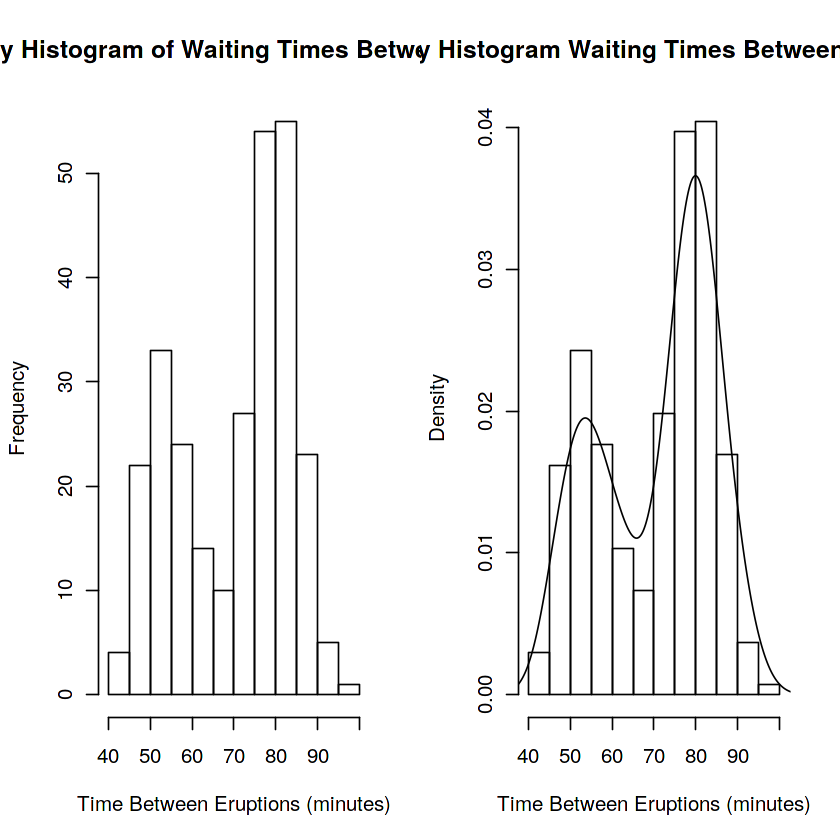

In [1]:
### Jared Yu
### Computational Statistics
### Project

### Fig. 1
# Compare frequency and density histograms
par(mfrow = c(1,2))
hist(faithful$waiting, main = 'Frequency Histogram of Waiting Times Between Eruptions',
     xlab = 'Time Between Eruptions (minutes)')
hist(faithful$waiting, main = 'Density Histogram Waiting Times Between Eruptions',
     xlab = 'Time Between Eruptions (minutes)', freq = FALSE)
lines(density(faithful$waiting))
dev.off()

### Fig. 2 (image from internet)
# check histogram settings for mathisfun
m <- 1
h <- 50
100 + m * h
100 + (m + 1) * h # Confirms break points of histogram

### Fig. 3
# Compare density histograms for different number of bins
par(mfrow = c(1,2))
hist(faithful$waiting, main = 'Frequency Histogram of Waiting Times Between Eruptions (breaks=default)',
     xlab = 'Time Between Eruptions (minutes)')
hist(faithful$waiting, main = 'Frequency Histogram of Waiting Times Between Eruptions (breaks=20)',
     xlab = 'Time Between Eruptions (minutes)', breaks = 20)
dev.off()

### Fig. 4
### The hist_est() function plots a histogram after separating the
### data into m intervals.
hist_est <- function(var1 = f12, m = 30, hist_tile, hist_x_lab, line_color = 'black') {
  var1_range <- range(var1) # range of data
  D <- var1_range[2] - var1_range[1] # ~length D of histogram
  v_k <- D / m # volume of bin (length of interval)
  n <- length(var1)
  
  break_pts <- matrix(NA, nrow = m + 1)
  break_pts[1] <- var1_range[1]; break_pts[m + 1] <- var1_range[2]
  for (i in 1:(m - 1)) { 
    break_pts[i + 1] <- var1_range[1] + i * v_k # possible bias towards right side
  } # create (m + 1) intervals
  break_pts <- as.vector(break_pts)
  
  m_bins <- matrix(0, nrow = m)
  for (i in var1) {
    lower_interval <- tail(which(i > break_pts), 1)
    if (i == break_pts[1]) { # edge case for smallest value
      m_bins[1] <- m_bins[1] + 1
    }
    m_bins[lower_interval] <- m_bins[lower_interval] + 1
  } # calculate the number of obs. in each bin
  
  p_k <- m_bins / n # proportion per bin
  f_hat <- p_k / v_k # est. histogram output
  
  # y_limits <- c(-0.05, max(f_hat_pts) + 0.5 * sd(f_hat_pts))
  y_limits <- c(0, max(f_hat) + 1e-2)
  # Reference: https://stackoverflow.com/questions/4785657/how-to-draw-an-empty-plot
  plot(1, type="n", ylab= "Estimated Density", xlim = var1_range, ylim = y_limits,
       main = paste0(hist_tile, ' (m=', m,')'),
       xlab = hist_x_lab)
       # main = paste0('Histogram Estimator (m=', m,')'))
  abline(h = 0)
  for (i in 1:length(f_hat)) {
    lines(c(break_pts[i], break_pts[i+1]), c(f_hat[i], f_hat[i]),
          col = line_color)
  } # plot horizontal and vertical lines of histogram
  segments(x0 = break_pts[-1], y0 = 0, x1 = break_pts[-1], y1 = f_hat, col = line_color)
  segments(x0 = break_pts[-length(break_pts)],
           y0 = 0, x1 = break_pts[-length(break_pts)], y1 = f_hat, col = line_color)
}

f12 <- read.csv('../input/kdedatafiles/F12.txt', header = FALSE) # load data
f12 <- log(f12[[1]]) # take log
par(mfrow = c(3,2)) # Plot grid of histograms for different 'm' bins
m_vec <- seq(from = 10, to = 60, length.out = 6)
for (i in m_vec) {
  hist_est(var1 = f12, m = i, hist_tile = 'Histogram of log F12',
           hist_x_lab = 'log F12')
  lines(density(f12))
}
dev.off()

### The rec_bins() function will determine the recommended
### number of bins to use based on the formula: 1+log_2(n)
rec_bins <- function(x) {
  n <- length(x)
  1 + log2(n)
}

rec_bins(f12) # 10.2


### Fig. 5
### The hist_est2() function provides the estimated probability based off
### the histogram estimate of the data. This is different
### from hist_est which plots the histogram.
hist_est2 <- function(x, var1 = f12, m = 30) {
  var1_range <- range(var1) # range of data
  
  # Check if x outside range of f-hat
  if ((x > var1_range[2]) | (x < var1_range[1])) {
    return(0)
  }
  
  D <- var1_range[2] - var1_range[1] # ~length D of histogram
  v_k <- D / m # volume of bin (length of interval)
  n <- length(var1)
  
  break_pts <- matrix(NA, nrow = m + 1)
  break_pts[1] <- var1_range[1]; break_pts[m + 1] <- var1_range[2]
  for (i in 1:(m - 1)) { 
    break_pts[i + 1] <- var1_range[1] + i * v_k # possible bias towards right side
  } # create (m + 1) intervals
  break_pts <- as.vector(break_pts)
  
  m_bins <- matrix(0, nrow = m)
  for (i in var1) {
    lower_interval <- tail(which(i > break_pts), 1)
    m_bins[lower_interval] <- m_bins[lower_interval] + 1
  } # calculate the number of obs. in each bin
  
  p_k <- m_bins / n # proportion per bin
  f_hat <- p_k / v_k # est. histogram output
  kth_bin <- tail(which(x >= break_pts), 1) # x's bin
  
  if ((kth_bin >= 1) & (kth_bin <= m)) {
    return(f_hat[kth_bin]) # return f-hat
  } else if (kth_bin == (m + 1)) {
    return(f_hat[m]) # edge case for last bin, return m'th bin
  } else {
    return(0)
  }
}

# vectorize the x argument
hist_est2_vec <- Vectorize(hist_est2, vectorize.args = c("x"))
xs <- seq(-3, 1.5, length.out = 1e4) # Plot the estimated histogram
plot(xs, hist_est2_vec(x = xs, var1 = f12, m = 40),
     type = 'l', main = 'Histogram Estimator and K.D.E. for log F12',
     xlab = 'log F12', ylab = 'Estimated Density')
lines(density(f12), lty = 2, col = 'red') # Add KDE for comparison
legend("topleft", legend = c('Histogram Estimator', 'K.D.E.'),
       lty = c(1,2), col = c('black', 'red'))
dev.off()

### Fig. 7
normal <- function(z) { # Normal kernel
  dnorm(z)
}

uniform <- function(z) { # Uniform kernel
  ifelse(abs(z) < 1, 1 / 2, 0)
}

epanechnikov <- function(z) { # Epanechnikov kernel
  ifelse(abs(z) < 1, (3 / 4) * (1 - z^2), 0)
}

triweight <- function(z) { # Triweight kernel
  ifelse(abs(z) < 1, (35 / 32) * ((1 - z^2)^3), 0)
}

# Silverman's rule of thumb
### The silverman function uses Silverman's rule of thumb
### for calculating the bandwidth.
silverman <- function(x) {
  n <- length(x)
  sigma_hat <- sd(x)
  h <- ((4 / (3 * n))^(1 / 5)) * sigma_hat
  return(h)
}
silverman_h <- silverman(x = f12)

# Sheather-Jones bandwidth using {locfit} package
sheather_jones_h <- locfit::sjpi(f12, silverman_h)[1]

# Terrell's maximal smoothing principle
### The maximal_smoothing_principle calculates the bandwidth
### using the method developed by Terrell that calculates
### the maximal smoothing principle.
maximal_smoothing_principle <- function(x) {
  n <- length(x)
  sigma_hat <- sd(x)
  R_K <- 1 / (2 * sqrt(pi))
  terrell_h <- 3 * ((R_K / (35 * n))^(1 / 5)) * sigma_hat
  return(terrell_h)
}

terrell_h <- maximal_smoothing_principle(x = f12)

### f_hat is the function that calculates the KDE estimate
### for a given x on the x-axis for a dataset, bandwidth,
### and kernel combination
f_hat <- function(x, X_i, h, K) {
  n <- length(X_i)
  (1 / h) * mean(K((x - X_i) / h))
}

f_hat_vec <- Vectorize(f_hat, vectorize.args = 'x') # Vectorize f_hat

par(mfrow = c(1,2)) # Compare kernels and bandwidths
# left-column: uniform, epanechnikov, triweight (m=40)
# right-column: normal (m=20, 40, 60) Silverman, Terrell, SJ
hist_est(var1 = f12, m = 40, # Plot a histogram (used twice)
  hist_tile = 'Histogram of log F12', hist_x_lab = 'log F12', line_color = 'gray')

# initialize variables for plotting
D <- range(f12); x_pts <- seq(D[1], D[2], length.out = 1e2)

f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # plot Uniform KDE

f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # plot Epanechnikov KDE

f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'black') # plot Triweight KDE

legend("topleft", legend = c('Uniform', 'Epanechnikov', 'Triweight'),
       lty = c(1,2,3), col = c('blue', 'red', 'black')) # add legend

f_hat_pts_sj <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = normal)
lines(x_pts, f_hat_pts_sj, lty = 1, col = 'blue') # add KDE
f_hat_pts_1.5 <- f_hat_vec(x = x_pts, X_i = f12, h = 1.5, K = normal)
lines(x_pts, f_hat_pts_1.5, lty = 2, col = 'red') # add KDE
f_hat_pts_0.05 <- f_hat_vec(x = x_pts, X_i = f12, h = 0.05, K = normal)
lines(x_pts, f_hat_pts_0.05, lty = 3, col = 'black') # add KDE
legend("topleft", legend = c('Sheather-Jones', '1.5', '0.05'),
       lty = c(1,2,3), col = c('blue', 'red', 'black'))
dev.off()

### Fig. 8
triangle <- function(z) { # Triangle kernel
  ifelse(abs(z) < 1, 1 - abs(z), 0)
}

biweight <- function(z) { # Biweight kernel
  ifelse(abs(z) < 1, (15 / 16) * ((1 - z^2)^2), 0)
}

xs <- seq(-3, 3, length.out = 1e5) # Compare different kernel densities
plot(xs, uniform(xs), type = 'l', ylim = c(0,1.1),
     main = 'Kernel Functions', col = 'black',
     xlab = latex2exp::TeX('z'), ylab = latex2exp::TeX('K(z)'))
lines(xs, normal(xs), lty = 2, col = 'red')
lines(xs, epanechnikov(xs), lty = 3, col = 'green')
lines(xs, triangle(xs), lty = 4, col = 'blue')
lines(xs, biweight(xs), lty = 5, col = 16)
lines(xs, triweight(xs), lty = 6, col = 'purple')
legend("topleft", legend = c('Uniform', 'Normal', 'Epanechnikov',
                             'Triangle', 'Biweght', 'Triweight'),
       lty = c(1:6), col = c('black', 'red', 'green', 'blue', 16, 'purple'))
dev.off()

### Fig. 9
### The scale_bandwidth() function will scale the bandwidth
### for one kernel and bandwidth combination (K) to another
### kernel and bandwidth combination (L).
scale_bandwidth <- function(h_K, delta_K, delta_L) {
  h_L <- (h_K / delta_K) * delta_L
  return(h_L)
}

# delta(K) values for bandwidth scaling
delta_normal <- (1 / (2 * sqrt(pi)))^(1 / 5)
delta_uniform <- (9 / 2)^(1 / 5)
delta_epanechnikov <- 15^(1 / 5)
delta_triangle <- 24^(1 / 5)
delta_biweight <- 35^(1/ 5)
delta_triweight <- (9450 / 143)^(1 / 5)

delta_vec <- c(delta_uniform, delta_epanechnikov, # vector for delta(K)
               delta_triangle, delta_biweight, delta_triweight)
# scale according to Normal kernel and Sheather-Jones bandwidth
scale_vec <- sapply(delta_vec, function(x)
  scale_bandwidth(h_K = sheather_jones_h,
                  delta_K = delta_normal, delta_L = x))

par(mfrow = c(1,2)) # Show the fit for different kernels
hist_est(var1 = f12, m = 40, # Plot a histogram (used twice)
         hist_tile = 'Histogram of log F12', hist_x_lab = 'log F12', line_color = 'gray')
# Left-hand side graph
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'black') # add KDE
legend("topleft", legend = c('Uniform', 'Epanechnikov', 'Triweight'),
       lty = c(1,2,3), col = c('blue', 'red', 'black'))

# Right-hand side graph
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = f12, h = sheather_jones_h, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 2) # add KDE
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = f12, h = scale_vec[1], K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = f12, h = scale_vec[2], K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = f12, h = scale_vec[5], K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'purple') # add KDE
legend("topleft", legend = c('Normal','Uniform', 'Epanechnikov', 'Triweight'),
       lty = c(1,1,2,3), lwd = c(2,1,1,1), col = c('black', 'blue', 'red', 'purple'))
dev.off()

### Computational Piece
### Dataset 1: Diabetes
diabetes <- read.csv('../input/kdedatafiles/diabetes.csv') # Load data

### Fig. 13
par(mfrow = c(3,3)) # Plot all the variables find ones that maybe worth investigating
var_description <- c( # Variable descriptions
  'Number of times pregnant',
  'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
  'Diastolic blood pressure (mm Hg)',
  'Triceps skin fold thickness (mm)',
  '2-Hour serum insulin (mu U/ml)',
  'Body mass index (weight in kg/(height in m)^2)',
  'Diabetes pedigree function',
  'Age (years)',
  'Class variable (0 or 1)'
)
for (i in 1:ncol(diabetes)) { # Plot grid of 9 variables
  hist(diabetes[,i], freq = FALSE,
       main = paste0('Histogram of ', colnames(diabetes)[i]),
       xlab = var_description[i])
  lines(density(diabetes[,i]))
}
dev.off()

### Age variable
par(mfrow = c(3,3)) # Try different 'm' bins
m_vec <- round(seq(25, 40, length.out = 9))
sapply(m_vec, function(x) { # Test different ranges for 'm'
  hist_est(var1 = diabetes$Age, m = x,
           hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
  lines(density(diabetes$Age))
})
dev.off()

### Fig. 14
par(mfrow = c(1,2)) # Compare chosen bins with default
hist(diabetes$Age, main = 'Default Histogram for Age',
     xlab = 'Age (years)', freq = FALSE)
lines(density(diabetes$Age))
hist_est(var1 = diabetes$Age, m = 32,
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
lines(density(diabetes$Age))
dev.off()

### Cross-Validation
### Fig. 15
# Calculate the Silverman and Sheather-Jones bandwidths for test
# bandwidths in cross-validation.
silverman_age <- silverman(x = diabetes$Age)
sheather_jones_age <- locfit::sjpi(x = diabetes$Age, a = silverman_age)[1]

### The cross_validation function calculates the cross-validation values
### for each of the observations in a variable. It returns a matrix
### of each of the cross-validation values.
cross_validation <- function(var1 = diabetes$Age, h = 0.3, K = normal) {
  n <- length(var1)
  i_not_j_vec <- 1:n
  cv_matrix <- matrix(NA, nrow = length(var1))
  K_i_not_j <- matrix(NA, nrow = length(var1))
  
  for (i in 1:n) {
    for (j in i_not_j_vec[-i]) {
      K_i_not_j[j] <- K((var1[i] - var1[j]) / h)
    }
    cv_matrix[i] <- (1 / (h * (n - 1))) * sum(K_i_not_j[,1], na.rm = TRUE)
    K_i_not_j <- matrix(NA, nrow = length(var1)) # reset to NA's
  }
  return(cv_matrix)
}

h_seq_age <- seq(sheather_jones_age - 2, # Test bandwidths for pseudo-likelihood
                 sheather_jones_age + 2, length.out = 1e2)

# Calculate and plot pseudo-likelihood values
pseudo_likelihood_age <- sapply(h_seq_age, function(x) {
  cv_output <- cross_validation(var1 = diabetes$Age,
                                h = sheather_jones_age, K = normal)
  prod(cv_output) # take the product of all the C-V values
})

plot(h_seq_age, pseudo_likelihood_age, type = 'l', # Plot the pseudo-likelihood
     main = 'Pseudo-likelihood vs Bandwidth',
     xlab = 'Bandwidth h', ylab = 'pseudo-likelihood')
dev.off()

### Fig. 16
### The UCV function calculates the unbiased cross-validation
### value for a variable given a bandwidth. It calculates the
### roughness of f-hat using a closed-form solution along with
### the expectation of f-hat using cross-validation to derive
### the final result.
UCV <- function(x, h = sheather_jones_age) {
  # First calculate R(f-hat)
  n <- length(x)

  upper_lower_triangle <- outer(X = x, Y = x, FUN = function(u, v) {
    exp((-1 / (4 * (h^2))) * ((u - v)^2))
  }) # apply f(u,v) to all elements of n*n matrix

  R_f <- (1 / ((n^2) * (h^2))) * # R(f-hat)
    ((h * sqrt(pi)) / (2 * pi)) * sum(upper_lower_triangle)
  
  # Calculate the 2*E[f-hat] term using cross-validation and combine with R_f
  ucv <- R_f - 2 * mean(cross_validation(var1 = x, h = h, K = normal))

  return(ucv)
}

# test values about S-J
ucv_seq_age <- seq(sheather_jones_age - 2, sheather_jones_age + 3, length.out = 20)
ucv_values_age <- sapply(ucv_seq_age, function(x) {
  UCV(x = diabetes$Age, h = x)
})

# optimal UCV bandwidth
ucv_h_age <- ucv_seq_age[which.min(ucv_values_age)] # 0.1990868
ucv_values_age[which.min(ucv_values_age)] # -0.1012167

par(mfrow = c(1,2)) # Plot UCV error and UCV histogram
plot(ucv_seq_age, ucv_values_age, type = 'l', # plot UCV results
     main = 'UCV vs. Bandwidth', xlab = 'Bandwidth h', ylab = 'UCV')
hist_est(var1 = diabetes$Age, m = 32,
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
D <- range(diabetes$Age); x_pts <- seq(D[1], D[2], length.out = 1e2)
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age, h = ucv_h_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'red', lwd = 1) # add KDE
legend("topright", legend = c('UCV'), col = 'red', lty = 1)
dev.off()

### Fig. 17
# Sheather-Jones / Silverman
silverman_age <- silverman(x = diabetes$Age) # 3.298613
locfit::sjpi(x = diabetes$Age, a = silverman_age)[1] # 1.672771
bw.SJ(x = diabetes$Age) # 1.007274
MASS::width.SJ(x = diabetes$Age) # 4.029095

### The sheather_jones_closed_form function calculates the roughness
### of the second derivative of the K.D.E. estimate using the Normal kernel.
### It then calculates the h-hat estimate for Sheather-Jones.
sheather_jones_closed_form <- function(X = f12, h_0 = silverman_h) {
  n <- length(X); R_K <- 1 / (2 * sqrt(pi)) # Initialize variables
  
  # Apply the closed form solution to all i,j elements
  A_B <- outer(X = X, Y = X, FUN = function(u, v) {
    D <- 1 / sqrt(2 * pi * ((h_0^2) / 2))
    H <- exp((-1 / (h_0^2)) * (((u^2 + v^2) / 2) - ((u + v) / 2)^2))
    mean_mu <- (u + v) / 2 # The mean and sd of the Normal g(x)
    sd_sigma <- sqrt((h_0^2) / 2)
    # The first 4 moments of the Normal distributions
    moment_4 <- mean_mu^4 + 3 * sd_sigma^4 + 6 * mean_mu^2 * sd_sigma^2
    moment_3 <- mean_mu^3 + 3 * mean_mu * sd_sigma^2
    moment_2 <- mean_mu^2 + sd_sigma^2
    moment_1 <- mean_mu
    B_prime <- -(2 * moment_3 * v)/h_0^4 + # 4th degree polynomial
      (moment_2 * v^2)/h_0^4 +
      (4 * u * moment_2 * v)/h_0^4 -
      (2 * u * moment_1 * v^2)/h_0^4 -
      (2 * u^2 * moment_1 * v)/h_0^4 +
      (u^2 * v^2)/h_0^4 +
      moment_4/h_0^4 -
      (2 * u * moment_3)/h_0^4 +
      (u^2 * moment_2)/h_0^4 +
      (2 * moment_1 * v)/h_0^2 -
      v^2/h_0^2 -
      (2 * moment_2)/h_0^2 +
      (2 * u * moment_1)/h_0^2 -
      u^2/h_0^2 + 1
    B <- (B_prime / D) * (H / (2 * pi))
    B
  })
  
  # Calculate h-hat
  roughness <- (1 / ((n^2) * (h_0^6))) * sum(A_B)
  h_hat <- (R_K / (n * roughness))^(1 / 5)
  return(h_hat)
}

s_j_closed_form_age <- sheather_jones_closed_form(X = diabetes$Age, h_0 = silverman_age)

# Monte Carlo Integration
### The MC_SJ function uses Monte Carlo Integration to estimate
### the roughness of the second derivative of the K.D.E. f-hat.
### The function assumes that the kernel function is the Normal
### kernel. It also uses the Silverman bandwidth for a pilot
### bandwidth. There are parameters to determine the approximation
### for the infinite bounds (A=1e4) and the number of MC iterations
### to try (n_MC). The function will output the S-J estimate.
MC_SJ <- function(x = diabetes$Age, h_0 = silverman_age, A = 1e4, n_MC = 1e3) {
  n <- length(x); R_K <- 1 / (2 * sqrt(pi)) # Initialize variables
  set.seed(0); u_sample <- runif(n = n_MC, min = -A, max = A)
  
  # Calculate g(x), where X~Unif[-A,A]
  MC_est <- sapply(u_sample, function(y) {
    squared_sum <- outer(X = x, Y = x, FUN = function(u, v) {
      (1 / (2 * pi)) *
        exp(-0.5 * ((y - u) / h_0)^2) * (1 - ((y - u) / h_0)^2) *
        exp(-0.5 * ((y - v) / h_0)^2) * (1 - ((y - v) / h_0)^2)
    })
    squared_sum <- sum(squared_sum)
    (2 * A) * squared_sum
  }
  )
  
  MC_avg <- mean(MC_est) # Take avg of MC results
  
  # Calculate S-J estimate with MC
  roughness_estimate <- (1 / ((n^2) * (h_0^6))) * MC_avg
  sheather_jones_MC <- (R_K / (n * roughness_estimate))^(1 / 5)
  
  return(sheather_jones_MC)
}

# Calculate the Sheather-Jones bandwidth using Monte Carlo Integration
sheather_jones_MC_age <- MC_SJ(x = diabetes$Age, # 1.515068
  h_0 = silverman_age, A = 1e4, n_MC = 1e3)

# Maximal smoothing principle
terrell_age <- maximal_smoothing_principle(x = diabetes$Age) # 3.562298

# Bandwidth scaling
# Uniform, Epanechnikov, Triangle, Biweight, Triweight
scale_vec_age <- sapply(delta_vec, function(x)
  scale_bandwidth(h_K = s_j_closed_form_age,
                  delta_K = delta_normal, delta_L = x))
scale_vec_age # 2.911476 3.704153 4.069236 4.388178 4.982988

par(mfrow = c(1,2)) # Compare results of different kernels
hist_est(var1 = diabetes$Age, m = 32, line_color = 'gray',
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
D <- range(diabetes$Age)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = s_j_closed_form_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 2) # add KDE
# Uniform
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                               h = scale_vec_age[1], K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
# Epanechnikov
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                    h = scale_vec_age[2], K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
legend("topright", legend = c('Normal', 'Uniform', 'Epanechnikov'),
       col = c('black', 'blue', 'red'), lty = c(1,1,2), lwd = c(2,1,1))
# Triangle
f_hat_pts_triangle <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                h = scale_vec_age[3], K = triangle)
lines(x_pts, f_hat_pts_triangle, lty = 1, col = 'red') # add KDE
# Biweight
f_hat_pts_biweight <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                h = scale_vec_age[4], K = biweight)
lines(x_pts, f_hat_pts_biweight, lty = 2, col = 'blue') # add KDE
# Triweight
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                                 h = scale_vec_age[5], K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'purple') # add KDE
legend("topright", legend = c('Normal', 'Triangle', 'Biweight', 'Triweight'),
       col = c('black', 'red', 'blue', 'purple'), lty = c(1,1,2,3), lwd = c(2,1,1,1))
dev.off()

### Fig. 18
# Plot Normal + different bandwidths
hist_est(var1 = diabetes$Age, m = 32, line_color = 'gray',
         hist_tile = 'Histogram of Age', hist_x_lab = 'Age (years)')
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = s_j_closed_form_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = silverman_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 2, col = 'red', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = diabetes$Age,
                              h = terrell_age, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 3, col = 'blue', lwd = 1) # add KDE
legend("topright", legend = c('Sheather-Jones', 'Silverman', 'Terrell'),
       lty = c(1,2,3), col = c('black', 'red', 'blue'))
dev.off()

### Fig. 19
# Explore difference
# can try to overlap KDE for the two groups
diab_pos <- diabetes[diabetes$Outcome == 1,]
diab_neg <- diabetes[diabetes$Outcome == 0,]

plot(density(diab_neg$Age), # Plot both groups' KDE
     main = 'K.D.E. of Age (Positive and Negative for Diabetes)',
     xlab = 'Age (years)')
lines(density(diab_pos$Age), col = 'red')
legend("topright", legend = c('Positive', 'Negative'),
       col = c('red', 'black'), lty = c(1,1))
dev.off()

### Dataset 1: Diabetes
wine <- read.csv('../input/kdedatafiles/winequality-red.csv') # Load data

### Fig. 20
par(mfrow = c(4,3))
# Reference: https://r.789695.n4.nabble.com/Replace-a-dot-in-a-string-quot-quot-with-a-space-quot-quot-td4726665.html
var_names <- sub("[.]", " ", sub("[.]", " ", colnames(wine)))
# Reference: https://stackoverflow.com/questions/6364783/capitalize-the-first-letter-of-both-words-in-a-two-word-string
var_names <- tools::toTitleCase(var_names)
var_description <- c(
  'fixed acidity',
  'amount of acetic acid',
  'citric acid',
  'amount of sugar after fermentation',
  'amount of salt',
  'free SO2',
  'total SO2',
  'density of wine',
  'acidic level pH',
  'sulphates',
  'percent alcohol',
  'quality score'
)
var_description <- tools::toTitleCase(var_description)

for (i in 1:ncol(wine)) { # Plot grid of variables hist/KDE
  hist(wine[,i], freq = FALSE,
       main = paste0('Histogram of ', var_names[i]),
       xlab = var_description[i])
  lines(density(wine[,i]))
}
dev.off()

### Fig. 21
par(mfrow = c(3,3)) # Try different 'm' bins
m_vec <- round(seq(10, 30, length.out = 9))
sapply(m_vec, function(x) {
  hist_est(var1 = wine$volatile.acidity, m = x,
           hist_tile = 'Histogram of Volatile Acidity',
           hist_x_lab = 'Amount of Acetic Acid')
  lines(density(wine$volatile.acidity))
})
dev.off()

par(mfrow = c(1,2)) # Compare chosen bins with default
hist(wine$volatile.acidity, main = 'Default Histogram for Volatile Acidity',
     xlab = 'Amount of Acetic Acid', freq = FALSE)
lines(density(wine$volatile.acidity))
hist_est(var1 = wine$volatile.acidity, m = 30,
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
lines(density(wine$volatile.acidity))
dev.off()

### Fig. 22
# Calculate Silverman/Sheather-Jones for cross-validation
silverman_volatile_acid <- silverman(x = wine$volatile.acidity)
sheather_jones_vol_acid <- locfit::sjpi(x = wine$volatile.acidity, a = silverman_volatile_acid)[1]
h_seq_vol_a <- seq(sheather_jones_vol_acid - 0.5,
                   sheather_jones_vol_acid + 2, length.out = 50)
pseudo_likelihood_vol_a <- sapply(h_seq_vol_a, function(x) {
  cv_output <- cross_validation(var1 = wine$volatile.acidity,
                                h = x, K = normal)
  prod(cv_output) # take the product of all the C-V values
})

plot(h_seq_vol_a, pseudo_likelihood_vol_a, # Plot pseudo-likelihood
     type = 'l', main = 'Pseudo-likelihood vs. Bandwidth',
     xlab = 'Bandwidth h', ylab = 'pseudo-likelihood')
h_seq_vol_a[which.min(pseudo_likelihood_vol_a)] # -0.007168466
dev.off()

### Fig. 23
# UCV
ucv_seq_vol_a <- seq(sheather_jones_vol_acid - 0.5,
                   sheather_jones_vol_acid + 2, length.out = 50)
ucv_values_vol_a <- sapply(ucv_seq_vol_a, function(x) {
  UCV(x = wine$volatile.acidity, h = x)
})

par(mfrow = c(1,2)) # Plot UCV optimum and KDE fit
plot(ucv_seq_vol_a, ucv_values_vol_a, type = 'l', main = 'UCV vs. Bandwidth',
     xlab = 'Bandwidth h', ylab = 'UCV')
ucv_h_vol_a <- ucv_seq_vol_a[which.min(ucv_values_vol_a)] # 0.04303562
ucv_values_vol_a[which.min(ucv_values_vol_a)] # -1.642159

hist_est(var1 = wine$volatile.acidity, m = 30,
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
D <- range(wine$volatile.acidity)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = ucv_h_vol_a, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'red', lwd = 1) # add KDE
legend("topright", legend = c('UCV'), col = 'red', lty = 1)
dev.off()

### Fig. 24
# Calculate Sheather-Jones used Monte Carlo Integration
silverman_volatile_acid <- silverman(x = wine$volatile.acidity) # 0.04337265
sheather_jones_vol_acid <- locfit::sjpi(x = wine$volatile.acidity, # 0.03283153
                                        a = silverman_volatile_acid)[1]
# sheather_jones_MC_vol_acid <- MC_SJ(x = wine$volatile.acidity,
  # h_0 = silverman_volatile_acid, A = 1e4, n_MC = 1e3)
# Result is Inf, so use ad-hoc trick for MC
h_0 = silverman_volatile_acid; A = 1e4; n_MC = 1e3 # code taken from MC_SJ() function
x <- wine$volatile.acidity; R_K <- 1 / (2 * sqrt(pi))
n <- length(x) # Initialize variables
set.seed(0)
u_sample <- runif(n = n_MC, min = -A, max = A)
u_sample[(u_sample <= 4) & (u_sample >= -4)] # None between -4 and 4
u_sample[1] <- 1 # Force a value to 1

# Calculate g(x), where X~Unif[-A,A]
### The g function is the squared sum calculation inside MC_est.
### By vectorizing this portion it's possible to check which values
### for u_sample will produce a non-zero value.
g <- function(y) {
  squared_sum <- outer(X = x, Y = x, FUN = function(u, v) {
    (1 / (2 * pi)) *
      exp(-0.5 * ((y - u) / h_0)^2) * (1 - ((y - u) / h_0)^2) *
      exp(-0.5 * ((y - v) / h_0)^2) * (1 - ((y - v) / h_0)^2)
  })
  squared_sum <- sum(squared_sum)
  (2 * A) * squared_sum
}

g_vec <- Vectorize(g, vectorize.args = c('y'))
test_values <- -10:10
non_zero_values <- which(g_vec(y = test_values) > 0)
test_values[non_zero_values] # Only -1, 0, 1, and 2 are non zero

MC_est <- sapply(u_sample[1], function(y) {
  squared_sum <- outer(X = x, Y = x, FUN = function(u, v) {
    (1 / (2 * pi)) *
      exp(-0.5 * ((y - u) / h_0)^2) * (1 - ((y - u) / h_0)^2) *
      exp(-0.5 * ((y - v) / h_0)^2) * (1 - ((y - v) / h_0)^2)
    })
    squared_sum <- sum(squared_sum)
    (2 * A) * squared_sum
  }
)
MC_avg <- mean(c(MC_est, rep(0, (n_MC - 1)))) # Same result after ad-hoc trick
# MC_avg <- mean(MC_est) # Take avg of MC results

# Calculate S-J estimate with MC
roughness_estimate <- (1 / ((n^2) * (h_0^6))) * MC_avg
sheather_jones_MC <- (R_K / (n * roughness_estimate))^(1 / 5)
# forced result using ad-hoc trick; 0.02150129 old value
sheather_jones_MC_vol_acid <- sheather_jones_MC # 0.03995043
bw.SJ(x = wine$volatile.acidity) # 0.03162348
MASS::width.SJ(x = wine$volatile.acidity) # 0.1264939
s_j_closed_form_vol_a <- sheather_jones_closed_form(X = wine$volatile.acidity,
  h_0 = silverman_volatile_acid) # 0.03283564, closed-form solution

# Calculate Terrell's bandwidth
terrell_volatile_acid <- maximal_smoothing_principle(x = wine$volatile.acidity) # 0.04683978

# Scale the bandwidths
scale_vec <- sapply(delta_vec, function(x)
  scale_bandwidth(h_K = s_j_closed_form_vol_a,
                  delta_K = delta_normal, delta_L = x))
scale_vec # 0.05713589 0.07269169 0.07985622 0.08611526 0.09778802

par(mfrow = c(1,2)) # Compare results
hist_est(var1 = wine$volatile.acidity, m = 30, line_color = 'gray',
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
D <- range(wine$volatile.acidity)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = sheather_jones_MC_vol_acid, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 2) # add KDE
# Uniform
f_hat_pts_uniform <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                               h = scale_vec[1], K = uniform)
lines(x_pts, f_hat_pts_uniform, lty = 1, col = 'blue') # add KDE
# Epanechnikov
f_hat_pts_epanechnikov <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                    h = scale_vec[2], K = epanechnikov)
lines(x_pts, f_hat_pts_epanechnikov, lty = 2, col = 'red') # add KDE
legend("topright", legend = c('Normal', 'Uniform', 'Epanechnikov'),
       col = c('black', 'blue', 'red'), lty = c(1,1,2), lwd = c(2,1,1))
# Triangle
f_hat_pts_triangle <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                h = scale_vec[3], K = triangle)
lines(x_pts, f_hat_pts_triangle, lty = 1, col = 'red') # add KDE
# Biweight
f_hat_pts_biweight <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                h = scale_vec[4], K = biweight)
lines(x_pts, f_hat_pts_biweight, lty = 2, col = 'blue') # add KDE
# Triweight
f_hat_pts_triweight <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                                 h = scale_vec[5], K = triweight)
lines(x_pts, f_hat_pts_triweight, lty = 3, col = 'purple') # add KDE
legend("topright", legend = c('Normal', 'Triangle', 'Biweight', 'Triweight'),
       col = c('black', 'red', 'blue', 'purple'), lty = c(1,1,2,3), lwd = c(2,1,1,1))
dev.off()

### Fig. 25
# Plot final choice of kernel/bandwidth with Silverman and Terrell
hist_est(var1 = wine$volatile.acidity, m = 30, line_color = 'gray',
         hist_tile = 'Histogram of Volatile Acidity',
         hist_x_lab = 'Amount of Acetic Acid')
D <- range(wine$volatile.acidity)
x_pts <- seq(D[1], D[2], length.out = 1e2) # sequence of x values for KDE
# Normal
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = s_j_closed_form_vol_a, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 1, col = 'black', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = silverman_volatile_acid, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 2, col = 'red', lwd = 1) # add KDE
f_hat_pts_normal <- f_hat_vec(x = x_pts, X_i = wine$volatile.acidity,
                              h = terrell_volatile_acid, K = normal)
lines(x_pts, f_hat_pts_normal, lty = 3, col = 'blue', lwd = 1) # add KDE
legend("topright", legend = c('Sheather-Jones', 'Silverman', 'Terrell'),
       lty = c(1,2,3), col = c('black', 'red', 'blue'))
dev.off()

### Fig. 26
# Explore difference
# can try to overlap KDE for the two groups
good_wine <- wine[wine$quality >= 7,]
bad_wine <- wine[wine$quality <= 6,]
plot(density(good_wine$volatile.acidity), # Plot both groups' KDE
     main = 'K.D.E. of Volatile Acidity', col = 'red',
     xlab = 'Amount of Acetic Acid')
lines(density(bad_wine$volatile.acidity), col = 'black')
legend("topright", legend = c('Good Wine (7+)', 'Bad Wine (<7)'),
       col = c('red', 'black'), lty = c(1,1))
dev.off()
